IMPORTING LIBRARIES

In [1]:
import os
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTANT: Enable experimental IterativeImputer FIRST
from sklearn.experimental import enable_iterative_imputer

#For processing and feature engineering
from sklearn.impute import(
    SimpleImputer,
    KNNImputer,
    IterativeImputer
)

from sklearn.feature_selection import(
    SelectKBest,
    SelectPercentile,
    RFE,
    RFECV,
    VarianceThreshold
)

from sklearn.preprocessing import(
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    Normalizer,
    PolynomialFeatures,
    OrdinalEncoder,
    LabelEncoder,
    KBinsDiscretizer,
    FunctionTransformer
)

#Model Selection and Evaluation

from sklearn.model_selection import(
    train_test_split,
    cross_val_predict,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    KFold,
    cross_validate
)

from sklearn.metrics import(
    accuracy_score,
    precision_recall_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    confusion_matrix,
    r2_score,
    classification_report,
    f1_score,
    recall_score,
    explained_variance_score,
    precision_score
)

# For Regresssion
from sklearn.linear_model import(
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    SGDRegressor,
    PassiveAggressiveRegressor
)

from sklearn.tree import(
    DecisionTreeRegressor
)

from sklearn.ensemble import(
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor,
    BaggingRegressor
)

from sklearn.svm import(
    SVR,
    LinearSVR
)
from sklearn.neighbors import(
    KNeighborsRegressor
)

from sklearn.neural_network import(
    MLPRegressor,
    _multilayer_perceptron
)

#For Classification

from sklearn.linear_model import(
    LogisticRegression,
    RidgeClassifier,
    Perceptron,
    PassiveAggressiveClassifier,
    SGDClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import(
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)

from sklearn.svm import(
    SVC,
    LinearSVC,
    NuSVC
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import(
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    CategoricalNB,
    ComplementNB
)

from sklearn.neural_network import MLPClassifier

from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis
)

from sklearn.impute import IterativeImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import scipy.stats as stats
from scipy.stats import (
    anderson,
    jarque_bera,
    shapiro,
    normaltest,
    kstest
)
from statsmodels.stats.diagnostic import lilliefors

from scipy.stats import zscore

from sklearn.feature_extraction import FeatureHasher

from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin





LOADING THE DATA


In [2]:
path=os.path.join('..','data','raw','used_cars.csv')
df=pd.read_csv(path)

BASIC INSPECTION


In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


Finding number of Rows and Columns in DataFrame


In [4]:
df.shape

(4009, 12)

BAsic Information about the datatframe

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


Milage and Price are shown as object data type which is not suitable for computation 
So we change them into float by removing 'L' and ','
Whereas in price we remove '$' and ','.

In [6]:
df['milage']=(df['milage']
.str.replace('mi.','')
.str.replace(',','')
.astype(float)
)
df['price']=(
    df['price']
    .str.replace('$','')
    .str.replace(',','')
    .astype(float)
)

In [7]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


Here is a example of feature engineering where we generate new feature from existing column.

In [8]:
df['Accident_occured']=(
    df['accident']
    .apply(lambda x:"NO" if x=='None reported' else "YES")
)

In [9]:
df.sample(20)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,Accident_occured
3929,Porsche,Cayenne AWD,2020,34580.0,Gasoline,335.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Red,None reported,Yes,56000.0,NO
3514,Jeep,Liberty Sport,2008,141485.0,Gasoline,210.0HP 3.7L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Gray,At least 1 accident or damage reported,Yes,6500.0,YES
190,Mercedes-Benz,Maybach S S 600,2016,108500.0,Gasoline,523.0HP 6.0L 12 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Beige,None reported,Yes,63500.0,NO
1972,Volvo,S80 T6,2009,97615.0,Gasoline,281.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed A/T,Black,Gray,None reported,Yes,10500.0,NO
2761,Porsche,911 Carrera S,2023,1877.0,Gasoline,443.0HP 3.0L Flat 6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Red,Red,None reported,Yes,185950.0,NO
709,MINI,Countryman Cooper S ALL4,2014,79000.0,Gasoline,181.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,None reported,Yes,17000.0,NO
363,Audi,A6 2.0T Premium Plus,2016,68000.0,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,At least 1 accident or damage reported,Yes,20000.0,YES
3661,Toyota,Tacoma PreRunner,2011,149000.0,Gasoline,236.0HP 4.0L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Beige,None reported,Yes,18995.0,NO
3734,Dodge,Dart SE,2013,153250.0,Gasoline,160.0HP 1.4L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Silver,Black,None reported,Yes,4399.0,NO
1304,BMW,M4 Base,2018,10950.0,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,White,White,None reported,Yes,60995.0,NO


We no longer need column called accident so we are removing it .

In [10]:
df.drop('accident',axis=1,inplace=True)

Now from enigine column we can xtract two data:
1.Engine Capacity (Volume of engine)
2.Horse power
To do so we use data extraction.

In [11]:

df['Engine_capacity']=(
    df['engine']
    .str.extract(r'(\d+\.\d+L|\d+L|\d+\.\d+\s+Liter|\d+\s+Liter )',flags=re.IGNORECASE)
)

In [12]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_occured,Engine_capacity
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7L
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8L
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,NO,3.5 Liter
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5L
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,NO,2.0L


In [13]:
df['Horse_Power']=(
    df['engine']
    .str.extract(r'(\d+\.\d+HP|\d+HP)',flags=re.IGNORECASE)
)

In [14]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_occured,Engine_capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7L,300.0HP
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8L,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,NO,3.5 Liter,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5L,354.0HP
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,NO,2.0L,NaN


Again We change the data type of Engine_capacity and Horse_Power so that computation on data can be done. 

In [15]:
df['Engine_capacity']=(
    df['Engine_capacity']
    .astype(str)
    .str.replace('Liter','')
    .str.replace('L','')
    .astype(float)
)

In [16]:
df['Horse_Power']=(
    df['Horse_Power']
    .str.replace('HP','')
    .astype(float)
)

In [17]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_occured,Engine_capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,NaN,54598.0,NO,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,NaN,34999.0,NO,2.0,NaN


Here we are checking Duplicated data.

In [18]:
df.duplicated().sum()

np.int64(0)

We can also check the memory Consumption

In [19]:
print(f"Memory Consumption: {round(df.memory_usage(deep=True).sum()/1024*1024,2)} MB")

Memory Consumption: 2313186.0 MB


Checking the null values in different field

In [20]:
df.isnull().sum()

brand                 0
model                 0
model_year            0
milage                0
fuel_type           170
engine                0
transmission          0
ext_col               0
int_col               0
clean_title         596
price                 0
Accident_occured      0
Engine_capacity     219
Horse_Power         808
dtype: int64

Usually the field with null values more than 10% are considered not useful for machine learning. So, we are checking the null values in percentage.

In [21]:
missing_info={}
for col in df.columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum())/len(df)*100
        missing_info[col]=round(missing_count,2)
print("\n Percentage of data missing in each column: \n")
for col,per in missing_info.items():
    print(f"{col}:{per}")


 Percentage of data missing in each column: 

fuel_type:4.24
clean_title:14.87
Engine_capacity:5.46
Horse_Power:20.15


Here We are checking the data for records with null value in associated column.

In [22]:
missing_hp_df=df[df['fuel_type'].isna()]

pd.set_option('display.max_rows',None) : This line of code helps to display all the records .


In [23]:
pd.set_option('display.max_rows',None)
missing_hp_df[['engine','fuel_type','brand','Horse_Power','clean_title']]

,engine,fuel_type,brand,Horse_Power,clean_title
9,534.0HP Electric Motor Electric Fuel System,NaN,Tesla,534.0,Yes
44,536.0HP Electric Motor Electric Fuel System,NaN,Lucid,536.0,Yes
68,536.0HP Electric Motor Electric Fuel System,NaN,Lucid,536.0,Yes
92,835.0HP Electric Motor Electric Fuel System,NaN,Rivian,835.0,Yes
122,835.0HP Electric Motor Electric Fuel System,NaN,Rivian,835.0,Yes
129,620.0HP Electric Motor Electric Fuel System,NaN,Lucid,620.0,NaN
155,455.0HP Electric Motor Electric Fuel System,NaN,Tesla,455.0,Yes
189,455.0HP Electric Motor Electric Fuel System,NaN,Tesla,455.0,Yes
225,670.0HP Electric Motor Electric Fuel System,NaN,Tesla,670.0,Yes
236,Electric,NaN,Polestar,NaN,NaN


We can fill the null values of clean_title with UNKNOWN so we are doing so.

In [24]:
df['clean_title']=df['clean_title'].fillna('UNKNOWN')

In [25]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_occured,Engine_capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,NaN
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,UNKNOWN,54598.0,NO,3.5,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,UNKNOWN,34999.0,NO,2.0,NaN


Here we are trying to find most unique brand of cars.

In [26]:
df['brand'].value_counts()

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
Lucid  

Here we are separating Numerical and Categorical column to perform different operations.

In [27]:
Numerical_Columns=df.select_dtypes(include=['number','float64', 'int64', 'float32','int32']).columns
Categorical_Columns=df.select_dtypes(include=['object', 'category']).columns

In [28]:
df[Numerical_Columns].head()

,model_year,milage,price,Engine_capacity,Horse_Power
0,2013,51000.0,10300.0,3.7,300.0
1,2021,34742.0,38005.0,3.8,NaN
2,2022,22372.0,54598.0,3.5,NaN
3,2015,88900.0,15500.0,3.5,354.0
4,2021,9835.0,34999.0,2.0,NaN


In [29]:
df[Categorical_Columns].head()

,brand,model,fuel_type,engine,transmission,ext_col,int_col,clean_title,Accident_occured
0,Ford,Utility Police Interceptor Base,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,Yes,YES
1,Hyundai,Palisade SEL,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,YES
2,Lexus,RX 350 RX 350,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,UNKNOWN,NO
3,INFINITI,Q50 Hybrid Sport,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,Yes,NO
4,Audi,Q3 45 S line Premium Plus,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,UNKNOWN,NO


In [30]:
df[Numerical_Columns].isnull().sum()

model_year           0
milage               0
price                0
Engine_capacity    219
Horse_Power        808
dtype: int64

Handeling Missing Columns

In [31]:
missing_info={}
for col in Numerical_Columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,3)
print("\n Columns with missing values in percentage \n")
for col,per in missing_info.items():
    print(f"{col}:{per}%")



 Columns with missing values in percentage 

Engine_capacity:5.463%
Horse_Power:20.155%


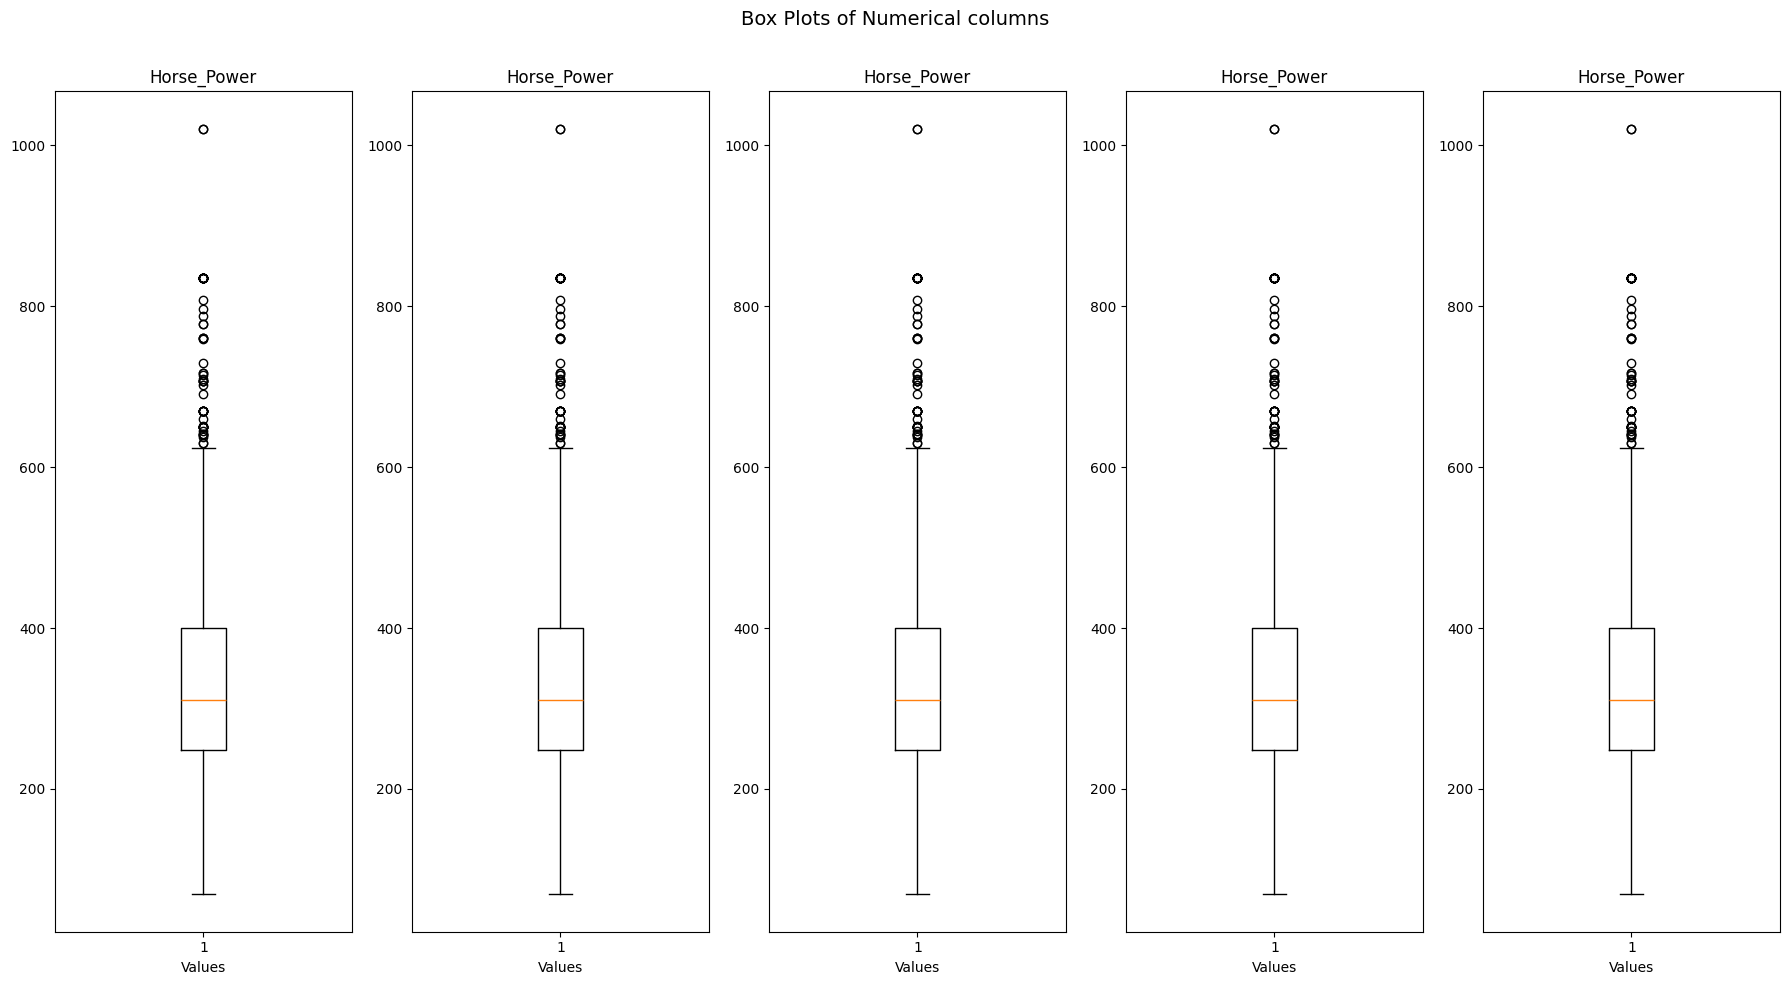

In [32]:
fig,axes=plt.subplots(1,5,figsize=(18,10))
for i,cols in enumerate(Numerical_Columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xlabel('Values')
plt.suptitle("Box Plots of Numerical columns",fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97]) 
plt.show()   

In [33]:
df.loc[df['Engine_capacity'].isnull(),['Engine_capacity','engine']]

,Engine_capacity,engine
9,NaN,534.0HP Electric Motor Electric Fuel System
10,NaN,V6
32,NaN,120 AH
44,NaN,536.0HP Electric Motor Electric Fuel System
68,NaN,536.0HP Electric Motor Electric Fuel System
92,NaN,835.0HP Electric Motor Electric Fuel System
120,NaN,V6
122,NaN,835.0HP Electric Motor Electric Fuel System
129,NaN,620.0HP Electric Motor Electric Fuel System
130,NaN,–


In [34]:
df['Engine_capacity']=(df['Engine_capacity']
                       .where(~df['engine']
                        .str.contains('Electric Motor Electric Fuel System',case=False,na=False),df['Engine_capacity'].fillna(0)))


In [35]:
df.loc[df['Engine_capacity'].isnull(),['Engine_capacity','engine','brand','fuel_type','model']]

,Engine_capacity,engine,brand,fuel_type,model
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
32,NaN,120 AH,BMW,Hybrid,i3 120Ah w/Range Extender
120,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0L Supercharged HSE
130,NaN,–,Chrysler,–,Pacifica Touring
236,NaN,Electric,Polestar,NaN,2 Launch Edition
257,NaN,–,Toyota,–,Land Cruiser Base
321,NaN,Electric,Chevrolet,NaN,Bolt EUV Premier
338,NaN,–,Mazda,–,Mazda3 s Grand Touring
383,NaN,Standard Range Battery,Ford,NaN,Mustang Mach-E Select
456,NaN,111.2Ah / FR 70kW / RR 160kW (697V),Kia,NaN,EV6 Wind


In [36]:
df['Engine_capacity']=(df['Engine_capacity']
                       .where(~df['engine']
                        .str.contains('Electric',case=False,na=False),df['Engine_capacity'].fillna(0)))


In [37]:
df.loc[df['Engine_capacity'].isnull(),['Engine_capacity','engine','brand','fuel_type','model']]

,Engine_capacity,engine,brand,fuel_type,model
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
32,NaN,120 AH,BMW,Hybrid,i3 120Ah w/Range Extender
120,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0L Supercharged HSE
130,NaN,–,Chrysler,–,Pacifica Touring
257,NaN,–,Toyota,–,Land Cruiser Base
338,NaN,–,Mazda,–,Mazda3 s Grand Touring
383,NaN,Standard Range Battery,Ford,NaN,Mustang Mach-E Select
456,NaN,111.2Ah / FR 70kW / RR 160kW (697V),Kia,NaN,EV6 Wind
491,NaN,–,Chrysler,–,Pacifica Touring
555,NaN,Dual Motor - Standard,Tesla,NaN,Model 3 Long Range


In [38]:
df['Engine_capacity']=(df['Engine_capacity']
                       .where(~df['engine']
                        .str.contains('Dual Motor - Standard',case=False,na=False),df['Engine_capacity'].fillna(0)))


In [39]:
df.loc[df['Engine_capacity'].isnull(),['Engine_capacity','engine','brand','fuel_type','model']]

,Engine_capacity,engine,brand,fuel_type,model
10,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0 Supercharged HST
32,NaN,120 AH,BMW,Hybrid,i3 120Ah w/Range Extender
120,NaN,V6,Land,Gasoline,Rover Range Rover Sport 3.0L Supercharged HSE
130,NaN,–,Chrysler,–,Pacifica Touring
257,NaN,–,Toyota,–,Land Cruiser Base
338,NaN,–,Mazda,–,Mazda3 s Grand Touring
383,NaN,Standard Range Battery,Ford,NaN,Mustang Mach-E Select
456,NaN,111.2Ah / FR 70kW / RR 160kW (697V),Kia,NaN,EV6 Wind
491,NaN,–,Chrysler,–,Pacifica Touring
686,NaN,V8,Land,Gasoline,Rover Range Rover Velar SVAutobiography Dynami...


In [40]:
print(f"Missing percentahe in Engine Capacity:{round((df['Engine_capacity'].isna().sum()/len(df))*100,3)}%")

Missing percentahe in Engine Capacity:1.372%


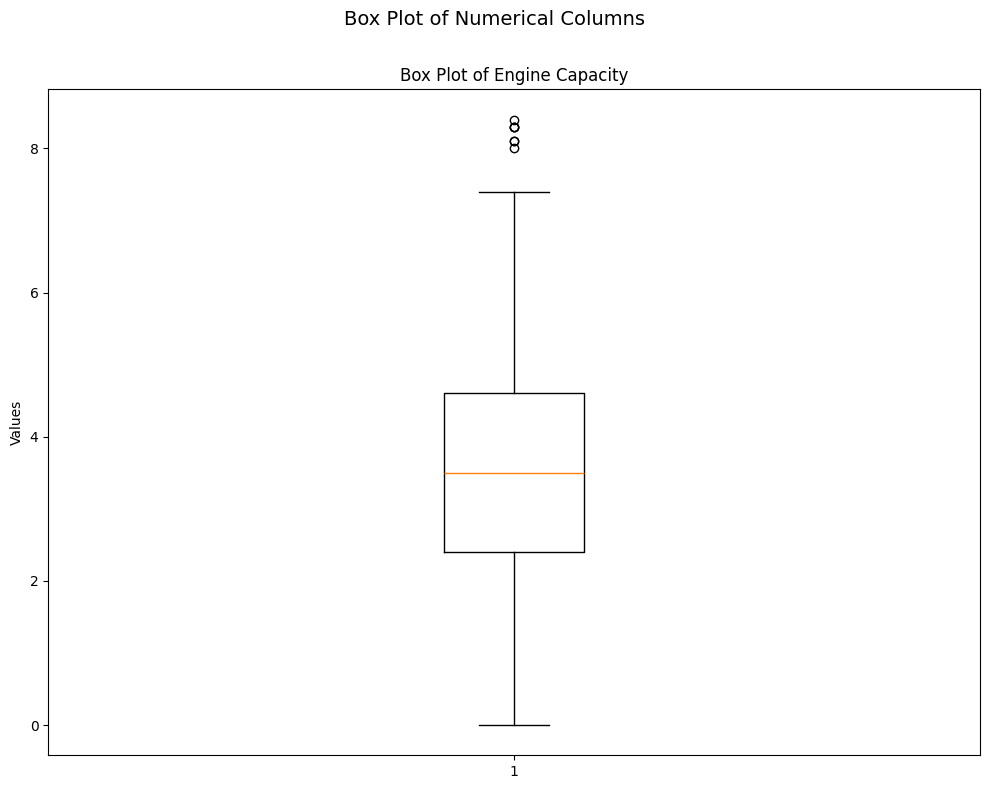

In [41]:
fig,axes=plt.subplots(figsize=(10,8))
axes.boxplot(df['Engine_capacity'].dropna())
axes.set_title("Box Plot of Engine Capacity")
axes.set_ylabel("Values")
plt.suptitle("Box Plot of Numerical Columns",fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

After observing the box plot above we decide to replace the remaining null values with median of the whole data as there are some outliers.

In [42]:
df['Engine_capacity']=df['Engine_capacity'].fillna(df['Engine_capacity'].median())

In [43]:
df.loc[df['Engine_capacity'].isnull(),['Engine_capacity','engine','brand','fuel_type','model']]

,Engine_capacity,engine,brand,fuel_type,model


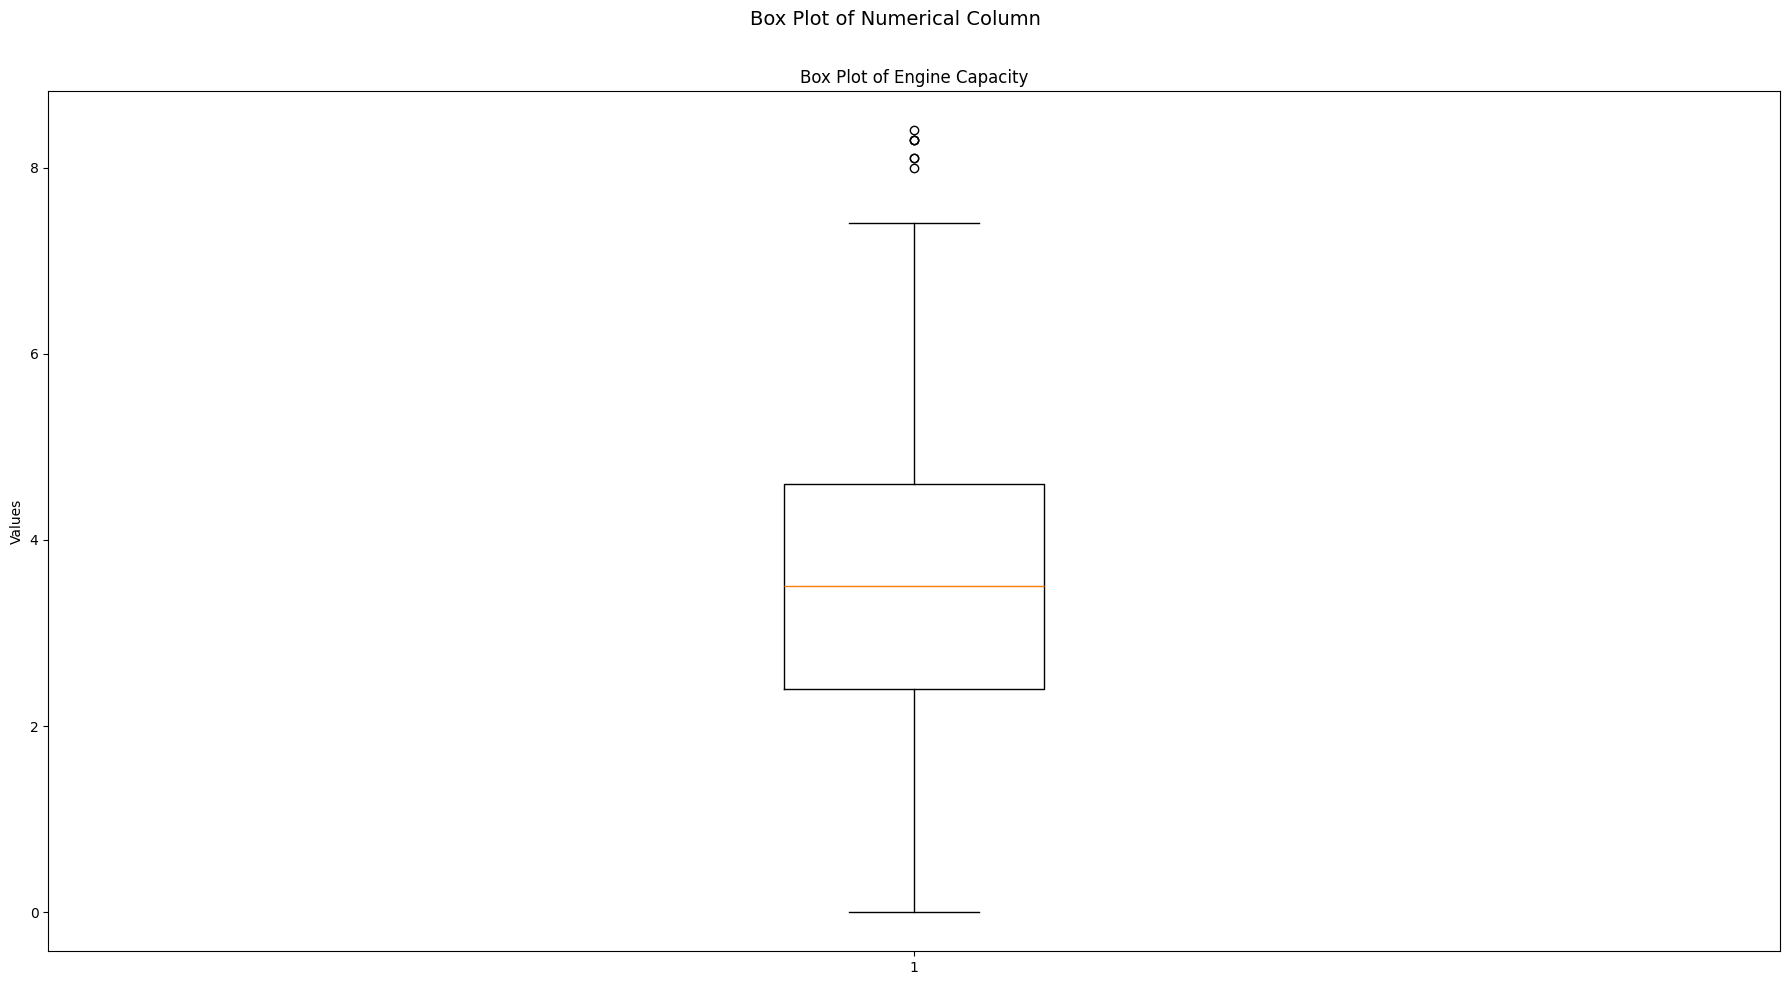

In [44]:
fig,axes=plt.subplots(figsize=(18,10))
axes.boxplot(df['Engine_capacity'].dropna())
axes.set_title("Box Plot of Engine Capacity")
axes.set_ylabel("Values")
plt.suptitle("Box Plot of Numerical Column",fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

In [45]:
print(f"Missing percentage in Engine Capacity:{round((df['Engine_capacity'].isna().sum()/len(df))*100,3)}%")

Missing percentage in Engine Capacity:0.0%


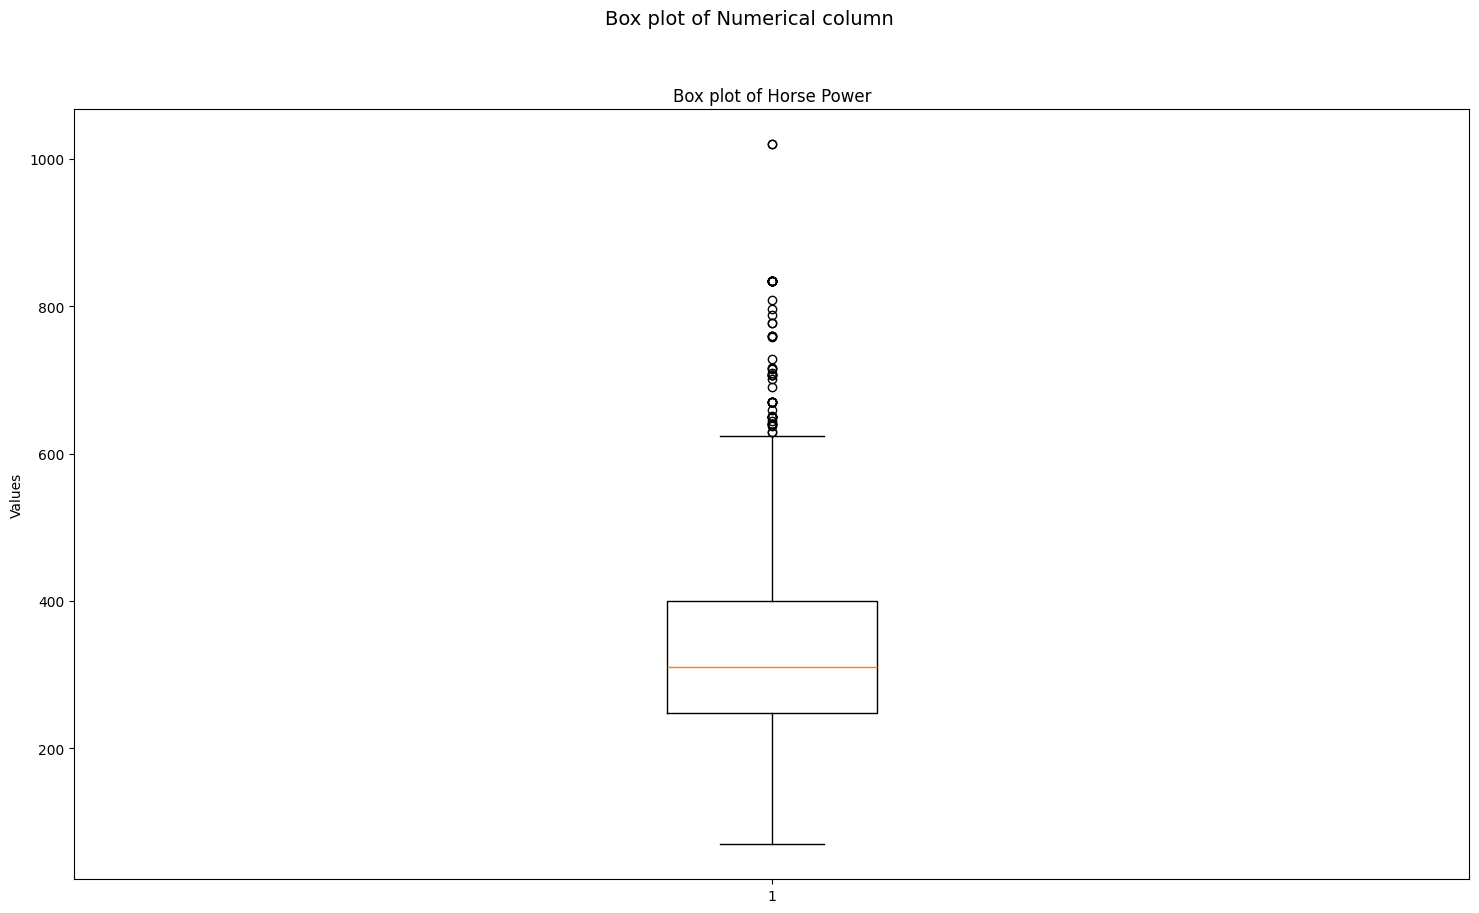

In [46]:
fig,axes=plt.subplots(figsize=(18,10))
axes.boxplot(df["Horse_Power"].dropna())
axes.set_title("Box plot of Horse Power")
axes.set_ylabel("Values")
plt.suptitle("Box plot of Numerical column",fontsize=14)
plt.show()

As there are lots of outliers in this box plot We ought to check the skewness of the data.

In [47]:
skew_value=df['Horse_Power'].skew()
print(f"The skewness of the horse power is {skew_value:.3f}")

The skewness of the horse power is 0.947


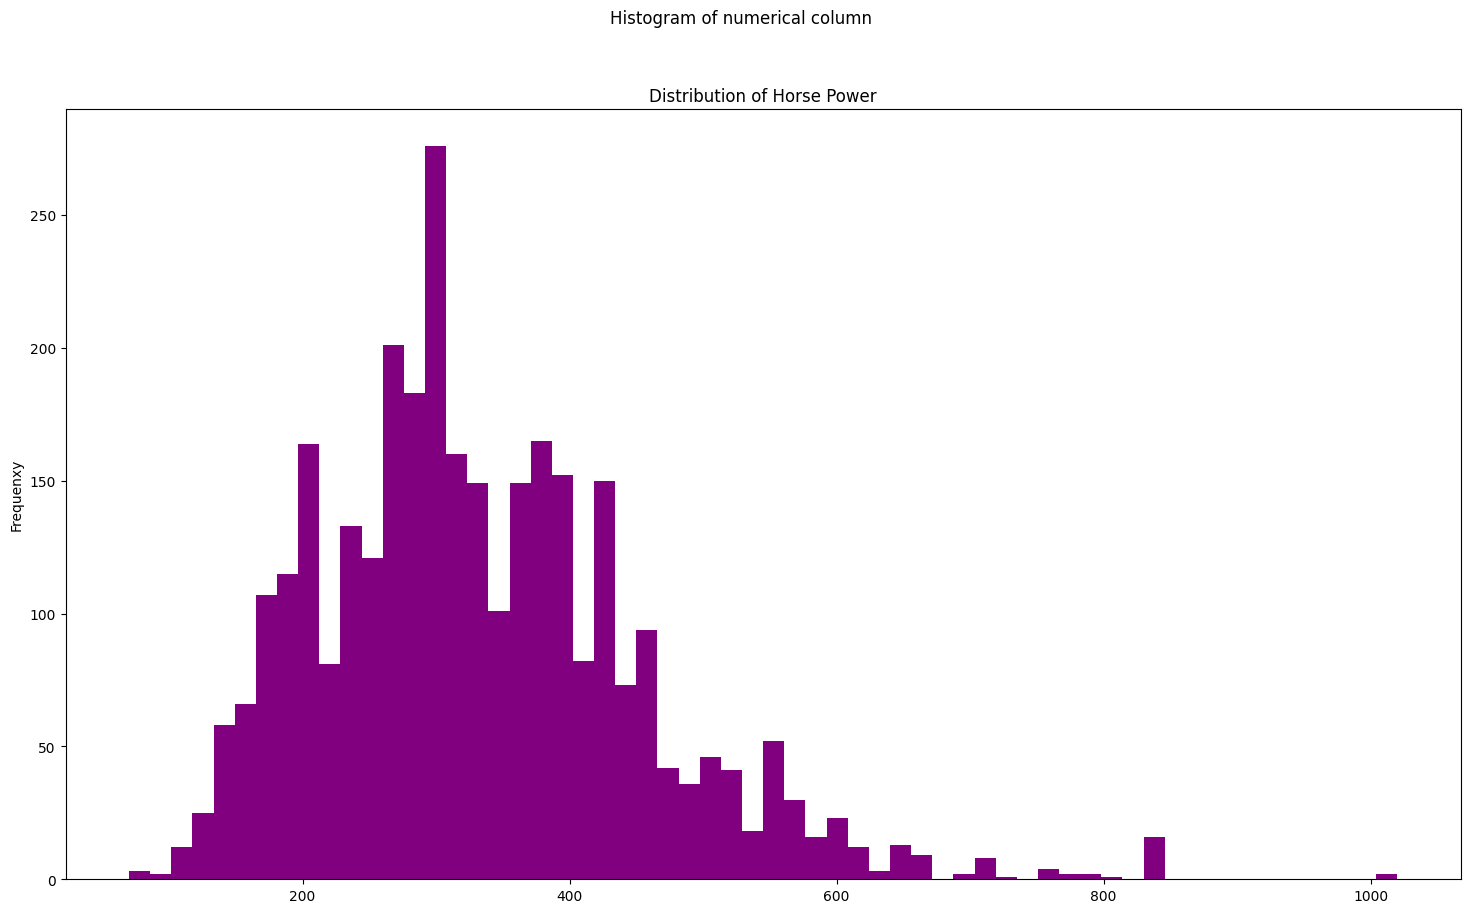

In [48]:
fig,axes=plt.subplots(figsize=(18,10))
axes.hist(df["Horse_Power"].dropna(),bins=60,color='purple')
axes.set_title('Distribution of Horse Power')
axes.set_ylabel('Horse Power')
axes.set_ylabel('Frequenxy')
plt.suptitle('Histogram of numerical column')
plt.show()

Now here we are predicticing the missing values of Horse Power

In [49]:
numeric_cols=['Engine_capacity','model_year','milage','Horse_Power','price']
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors='coerce')

known=df[df['Horse_Power'].notna()]
missing=df[df['Horse_Power'].isna()]

numerical_features=['Engine_capacity','model_year','milage','price']
categorical_features=['brand']

prepocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ],
    remainder='passthrough'
)

pipeline=Pipeline(steps=[
    ('preprocessors',prepocessor),
    ('regressor',LinearRegression())
])

pipeline.fit(
    known[categorical_features+numerical_features],
    known['Horse_Power']
)

predicted_horsepower=pipeline.predict(missing[categorical_features+numerical_features])

df.loc[df['Horse_Power'].isna(),'Horse_Power']=predicted_horsepower 
#This line of code make sure the predicted horse power are positive value as the model can also predict negative value

df['Horse_Power']=df['Horse_Power'].clip(lower=0)
print("All the missing values are filled with linear regression imputation technique.")

All the missing values are filled with linear regression imputation technique.


In [50]:
missing_info={}
for col in Numerical_Columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,3)
print("\n Columns with missing values in percentage \n")
for col,per in missing_info.items():
    print(f"{col}:{per}%")



 Columns with missing values in percentage 



In [51]:
### Handeling Missing values of Categorical columns

In [52]:
missing_info={}
for col in Categorical_Columns:
    if df[col].isnull().sum()>0:
        missing_count=(df[col].isnull().sum()/len(df))*100
        missing_info[col]=round(missing_count,3)
print("\n Columns with missing values in percentage \n")
for col,per in missing_info.items():
    print(f"{col}:{per}%")



 Columns with missing values in percentage 

fuel_type:4.24%


In [53]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)
df.loc[df['fuel_type'].isna(),['fuel_type','engine','transmission']]

,fuel_type,engine,transmission
9,NaN,534.0HP Electric Motor Electric Fuel System,A/T
44,NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T
68,NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T
92,NaN,835.0HP Electric Motor Electric Fuel System,1-Speed A/T
122,NaN,835.0HP Electric Motor Electric Fuel System,A/T
129,NaN,620.0HP Electric Motor Electric Fuel System,A/T
155,NaN,455.0HP Electric Motor Electric Fuel System,A/T
189,NaN,455.0HP Electric Motor Electric Fuel System,1-Speed A/T
225,NaN,670.0HP Electric Motor Electric Fuel System,A/T
236,NaN,Electric,1-Speed Automatic


In [54]:
df['fuel_type']=df['fuel_type'].fillna('Electric')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_occured,Engine_capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,386.175639
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,UNKNOWN,54598.0,NO,3.5,392.374551
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,UNKNOWN,34999.0,NO,2.0,334.254113


In [55]:
df['Cylinders']=(
    df['engine']
    .str.extract(r'(v+\d)',flags=re.IGNORECASE)
)
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_occured,Engine_capacity,Horse_Power,Cylinders
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000,V6
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,Yes,38005.0,YES,3.8,386.175639,V6
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,UNKNOWN,54598.0,NO,3.5,392.374551,NaN
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000,V6
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,UNKNOWN,34999.0,NO,2.0,334.254113,NaN


In [56]:
df['Cylinders'].count()

np.int64(1210)

In [57]:
df.loc[df["ext_col"]==df["int_col"],['brand','model','model_year','milage','fuel_type','engine','transmission','ext_col','int_col','clean_title','price','Accident_occured','Engine_capacity','Horse_Power']].head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,clean_title,price,Accident_occured,Engine_capacity,Horse_Power
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,10300.0,YES,3.7,300.000000
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,Yes,15500.0,NO,3.5,354.000000
7,BMW,740 iL,2001,242000.0,Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,Yes,7300.0,NO,4.4,282.000000
8,Lexus,RC 350 F Sport,2021,23436.0,Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,Yes,41927.0,NO,3.5,311.000000
9,Tesla,Model X Long Range Plus,2020,34000.0,Electric,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,Yes,69950.0,NO,0.0,534.000000
25,Hyundai,Elantra N Base,2022,11650.0,Gasoline,276.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,Yes,32300.0,NO,2.0,276.000000
32,BMW,i3 120Ah w/Range Extender,2020,35035.0,Hybrid,120 AH,Automatic,Black,Black,UNKNOWN,24998.0,NO,3.5,368.182543
33,Kia,Sorento SX,2011,171000.0,Gasoline,276.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,Yes,5999.0,NO,3.5,276.000000
40,Bentley,Continental GTC Base,2011,20200.0,E85 Flex Fuel,552.0HP 6.0L 12 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,Yes,79950.0,NO,6.0,552.000000
47,MINI,Convertible John Cooper Works,2017,24280.0,Gasoline,228.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,Yes,29000.0,YES,2.0,228.000000


In [58]:
External_Colors=(df['ext_col'].str.strip().str.lower().value_counts(normalize=True)*100).round(2)
print("Unique ext_col colours in percentage:", External_Colors)




Unique ext_col colours in percentage: ext_col
black                                      22.65
white                                      20.35
gray                                       12.37
silver                                      9.33
blue                                        8.73
red                                         6.51
green                                       1.85
brown                                       1.07
gold                                        1.05
beige                                       0.95
orange                                      0.90
yellow                                      0.72
–                                           0.37
summit white                                0.35
diamond black                               0.35
bright white clearcoat                      0.35
purple                                      0.30
alpine white                                0.20
granite crystal clearcoat metallic          0.17
silver ice metallic    

In [59]:
Internal_Colors=(df['int_col'].str.strip().str.lower().value_counts(normalize=True)*100).round(2)
print("Unique int_col colours in percentage:", Internal_Colors)


Unique int_col colours in percentage: int_col
black                         50.61
beige                         13.44
gray                          11.77
brown                          3.92
–                              3.32
white                          3.19
red                            3.14
jet black                      1.47
ebony                          1.10
blue                           0.72
orange                         0.52
silver                         0.40
global black                   0.32
charcoal                       0.30
nero ade                       0.25
gold                           0.25
graphite                       0.20
green                          0.17
diesel gray / black            0.15
black onyx                     0.12
charcoal black                 0.12
parchment                      0.12
black / express red            0.10
rioja red                      0.10
tan                            0.10
satin black                    0.10
medium earth gray 

In [60]:


# Function to combine small categories
def combine_small_categories(data, threshold_percent=5, others_name='Others'):
    """
    Combine categories with percentage less than threshold into 'Others'
    
    Parameters:
    data: pandas Series with percentages
    threshold_percent: minimum percentage to keep as separate category
    others_name: name for the combined category
    
    Returns:
    pandas Series with combined categories
    """
    # Create a copy to avoid modifying original
    data_copy = data.copy()
    
    # Identify categories below threshold
    small_categories = data_copy[data_copy < threshold_percent].index
    
    # Combine small categories into 'Others'
    if len(small_categories) > 0:
        others_sum = data_copy[small_categories].sum()
        # Keep only categories above threshold
        combined_data = data_copy[~data_copy.index.isin(small_categories)]
        # Add 'Others' category
        combined_data[others_name] = others_sum
        # Sort by value descending
        combined_data = combined_data.sort_values(ascending=False)
        return combined_data
    else:
        return data_copy

# Define threshold (you can change this value)
THRESHOLD_PERCENT = 1.5 # Categories below 5% will be grouped as 'Others'

# Apply the combination
External_Colors_Combined = combine_small_categories(External_Colors, THRESHOLD_PERCENT)
Internal_Colors_Combined = combine_small_categories(Internal_Colors, THRESHOLD_PERCENT)




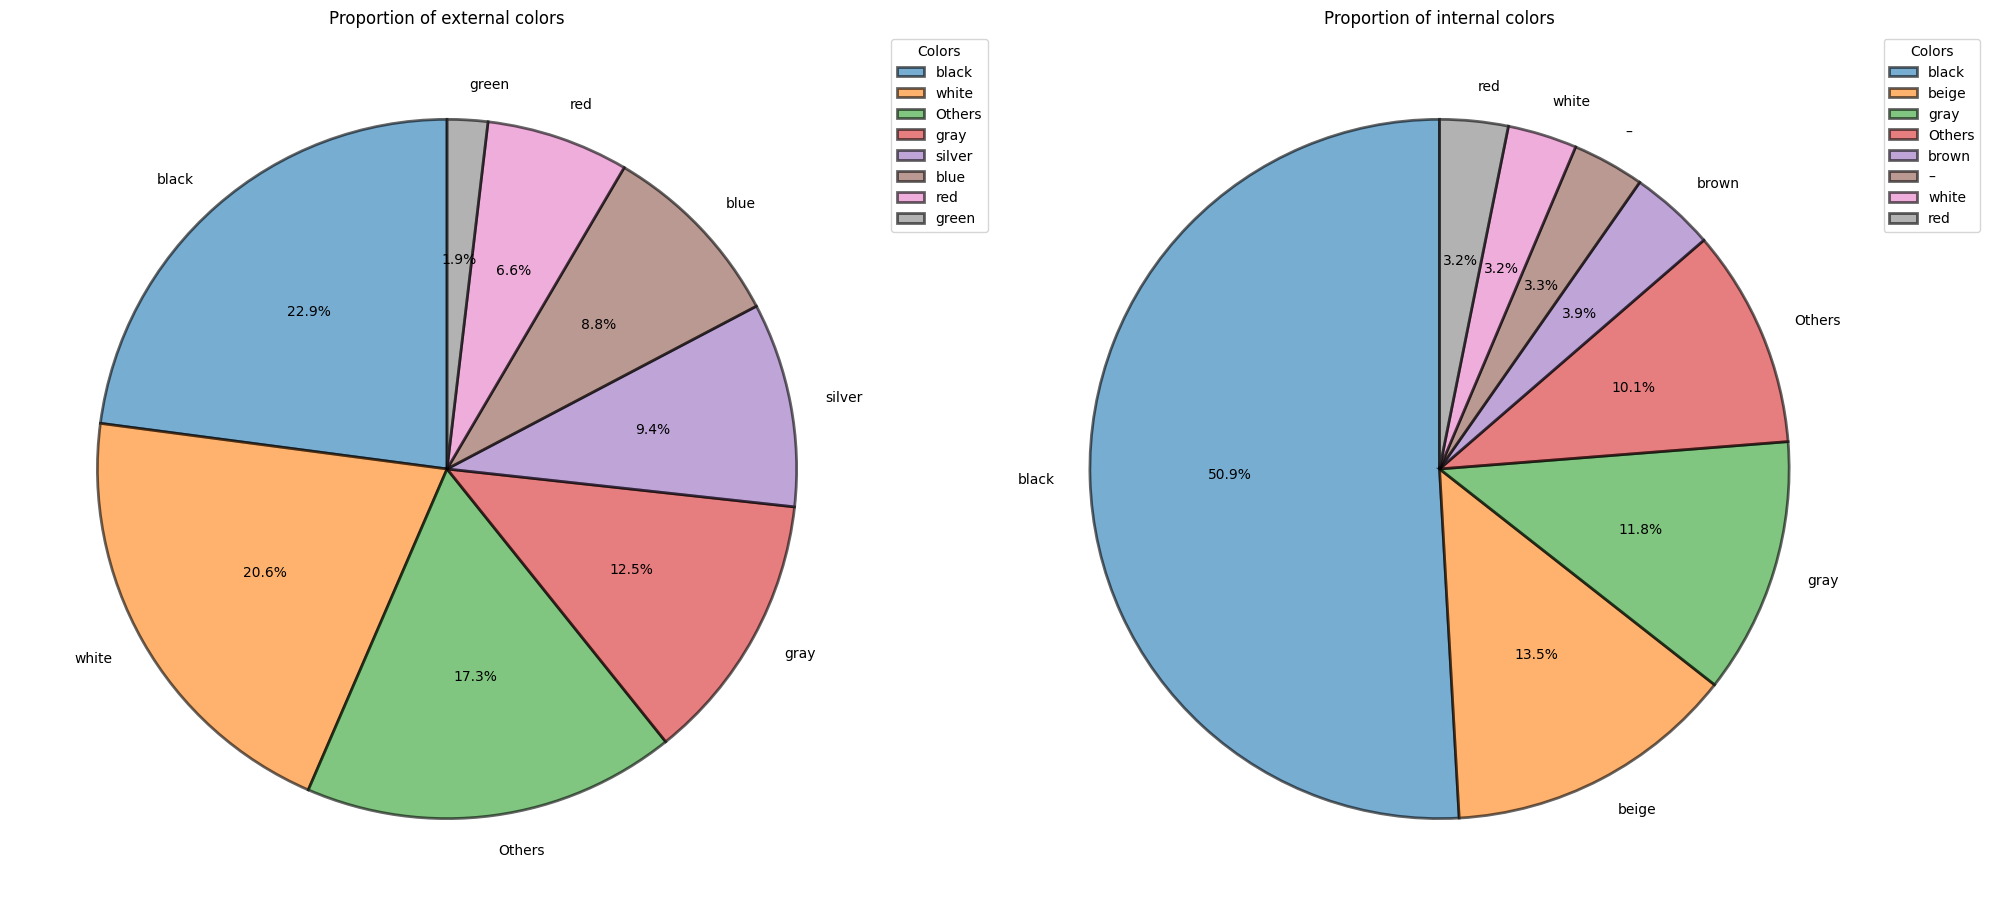

In [61]:
fig,axes=plt.subplots(1,2,figsize=(20,15))

axes[0].pie(External_Colors_Combined,
            labels=External_Colors_Combined.index,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 2, 'alpha': 0.6}
            )
axes[0].set_title("Proportion of external colors")
axes[0].legend( External_Colors_Combined.index,
               title="Colors",
               loc="upper left",
               bbox_to_anchor=(1, 0, 0.5, 1),
               fontsize=10
)

axes[1].pie(Internal_Colors_Combined,
            labels=Internal_Colors_Combined.index,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 2, 'alpha': 0.6}
            )
axes[1].set_title("Proportion of internal colors")
axes[1].legend( Internal_Colors_Combined.index,
               title="Colors",
               loc="upper left",
               bbox_to_anchor=(1, 0, 0.5, 1),
               fontsize=10
)

plt.tight_layout()
plt.show()

In [62]:
df.loc[df['fuel_type']=='–',['fuel_type','engine','Engine_capacity','model','brand']]

,fuel_type,engine,Engine_capacity,model,brand
130,–,–,3.5,Pacifica Touring,Chrysler
257,–,–,3.5,Land Cruiser Base,Toyota
338,–,–,3.5,Mazda3 s Grand Touring,Mazda
491,–,–,3.5,Pacifica Touring,Chrysler
692,–,–,3.5,Civic EX,Honda
855,–,–,3.5,Bronco,Ford
923,–,–,3.5,Challenger R/T,Dodge
995,–,–,3.5,Challenger R/T Scat Pack,Dodge
1063,–,–,3.5,Mazda6 i Grand Touring,Mazda
1083,–,–,3.5,Challenger R/T,Dodge


In [63]:
df.loc[df['model'].str.contains('E-Class D', case=False, na=False), 'fuel_type'] = 'Diesel'

In [64]:
mask = (
    (df['fuel_type']=='–') &
    df['model'].isin([
        'Pacifica Touring',
        'Land Cruiser Base',
        'Mazda3 s Grand Touring',
        'Civic EX',
        'Bronco',
        'Challenger R/T',
        'Challenger R/T Scat Pack',
        'Mazda6 i Grand Touring',
        'Sonic LT',
        'MX-5 Miata Base',
        'E-Class 400E',
        '1500 Cheyenne Extended Cab',
        'Phantom',
        'Mustang EcoBoost Premium',
        'Integra GS-R',
        '300ZX Base',
        'Capri XR2',
        '240SX Base',
        '850 Turbo',
        'Challenger SRT 392',
        'NSX Base',
        '1500 Cheyenne',
        'XJ6 Vanden Plas',
        'Challenger SRT8',
        'DeVille Base',
        'Wrangler S',
        '911 Carrera',
        'Pickup Truck XE',
        'Bronco XLT',
        '200 Limited',
        'F-250 XL SuperCab H/D',
        'Challenger SRT8 392',
        'Sierra 1500 SLE1 Extended Cab',
        '911 Carrera Cabriolet',
        'Protege DX',
        'Ram 3500 Quad Cab DRW'
    ])
)

df.loc[mask, 'fuel_type'] = 'Gasoline'

In [65]:
df.loc[df['fuel_type']=='–',['fuel_type','engine','Engine_capacity','model','brand']]

,fuel_type,engine,Engine_capacity,model,brand


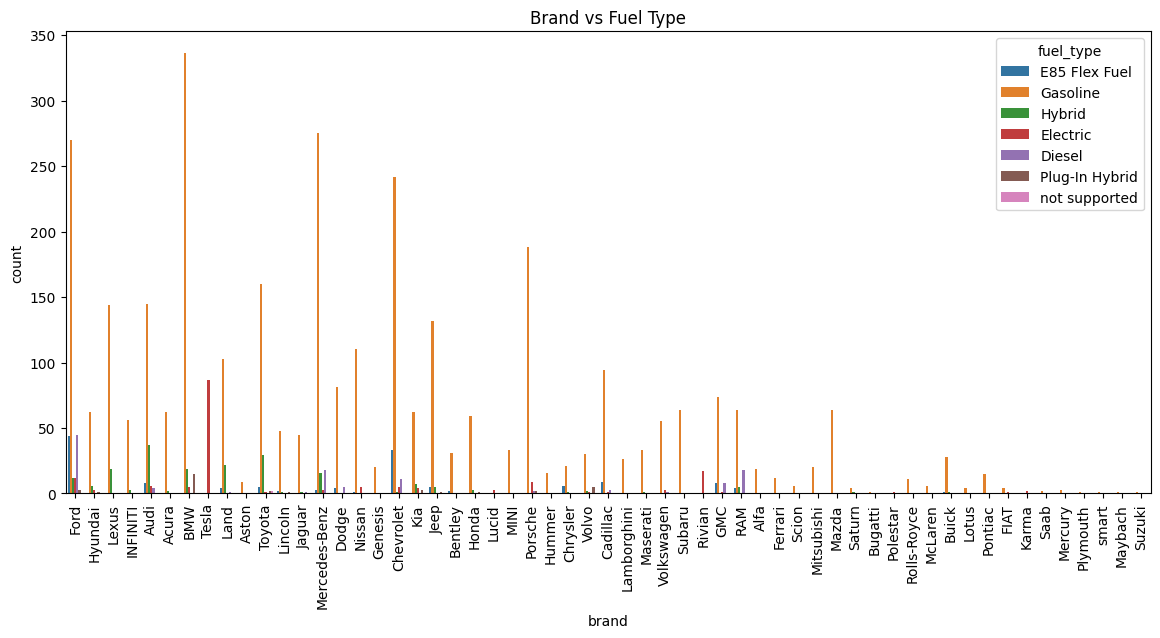

In [66]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='brand', hue='fuel_type')
plt.xticks(rotation=90)
plt.title("Brand vs Fuel Type")
plt.show()

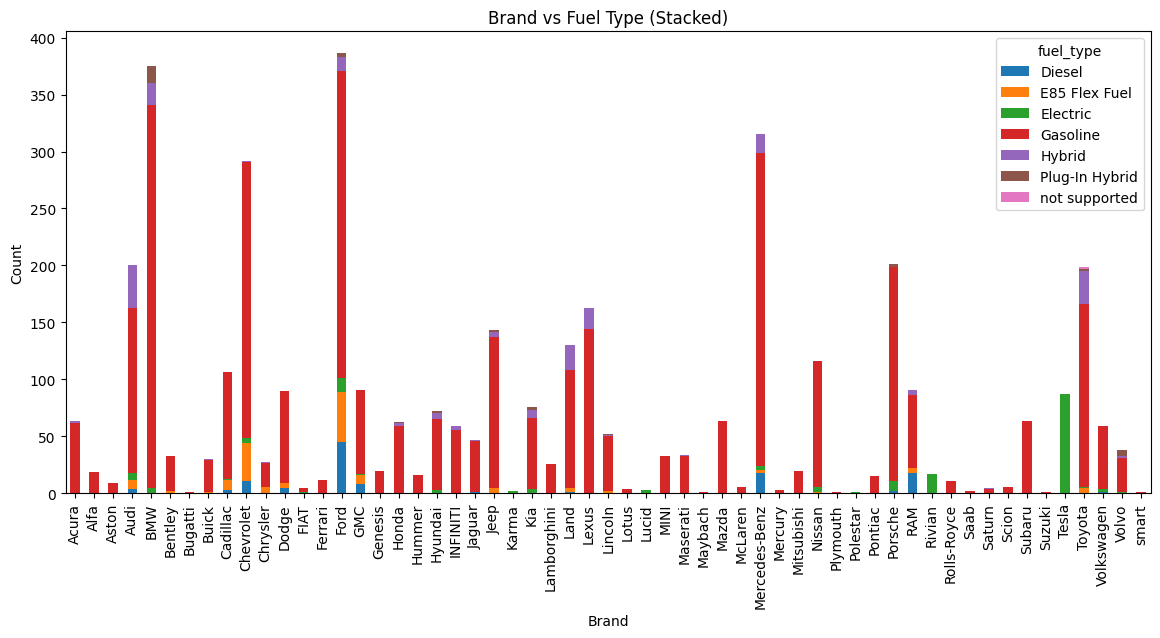

In [67]:
brand_fuel = pd.crosstab(df['brand'], df['fuel_type'])
brand_fuel.plot(kind='bar', stacked=True, figsize=(14,6))

plt.title("Brand vs Fuel Type (Stacked)")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

OUTLIER DETECTION for numrical columns

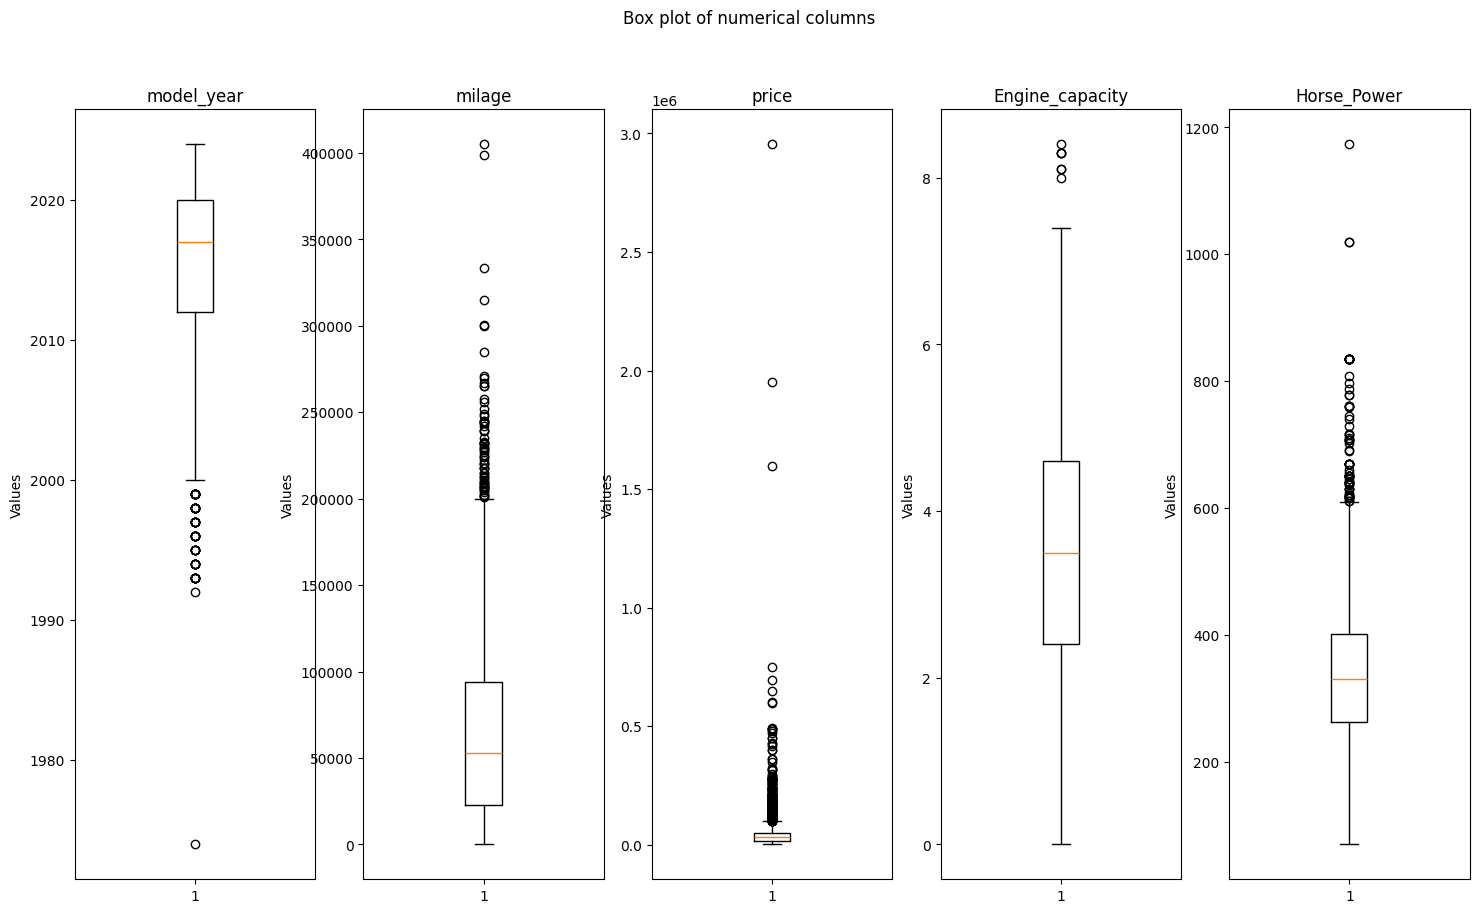

In [68]:
fig,axes=plt.subplots(1,len(Numerical_Columns),figsize=(18,10))
for i , cols in enumerate(Numerical_Columns):
    axes[i].boxplot(df[cols].dropna())
    axes[i].set_title(cols)
    axes[i].set_ylabel("Values")
    plt.suptitle("Box plot of numerical columns")
plt.show()

<h1>Methods for Testing Normality

<h2>1. Visual Method

Histogram with kde and Q-Q plots

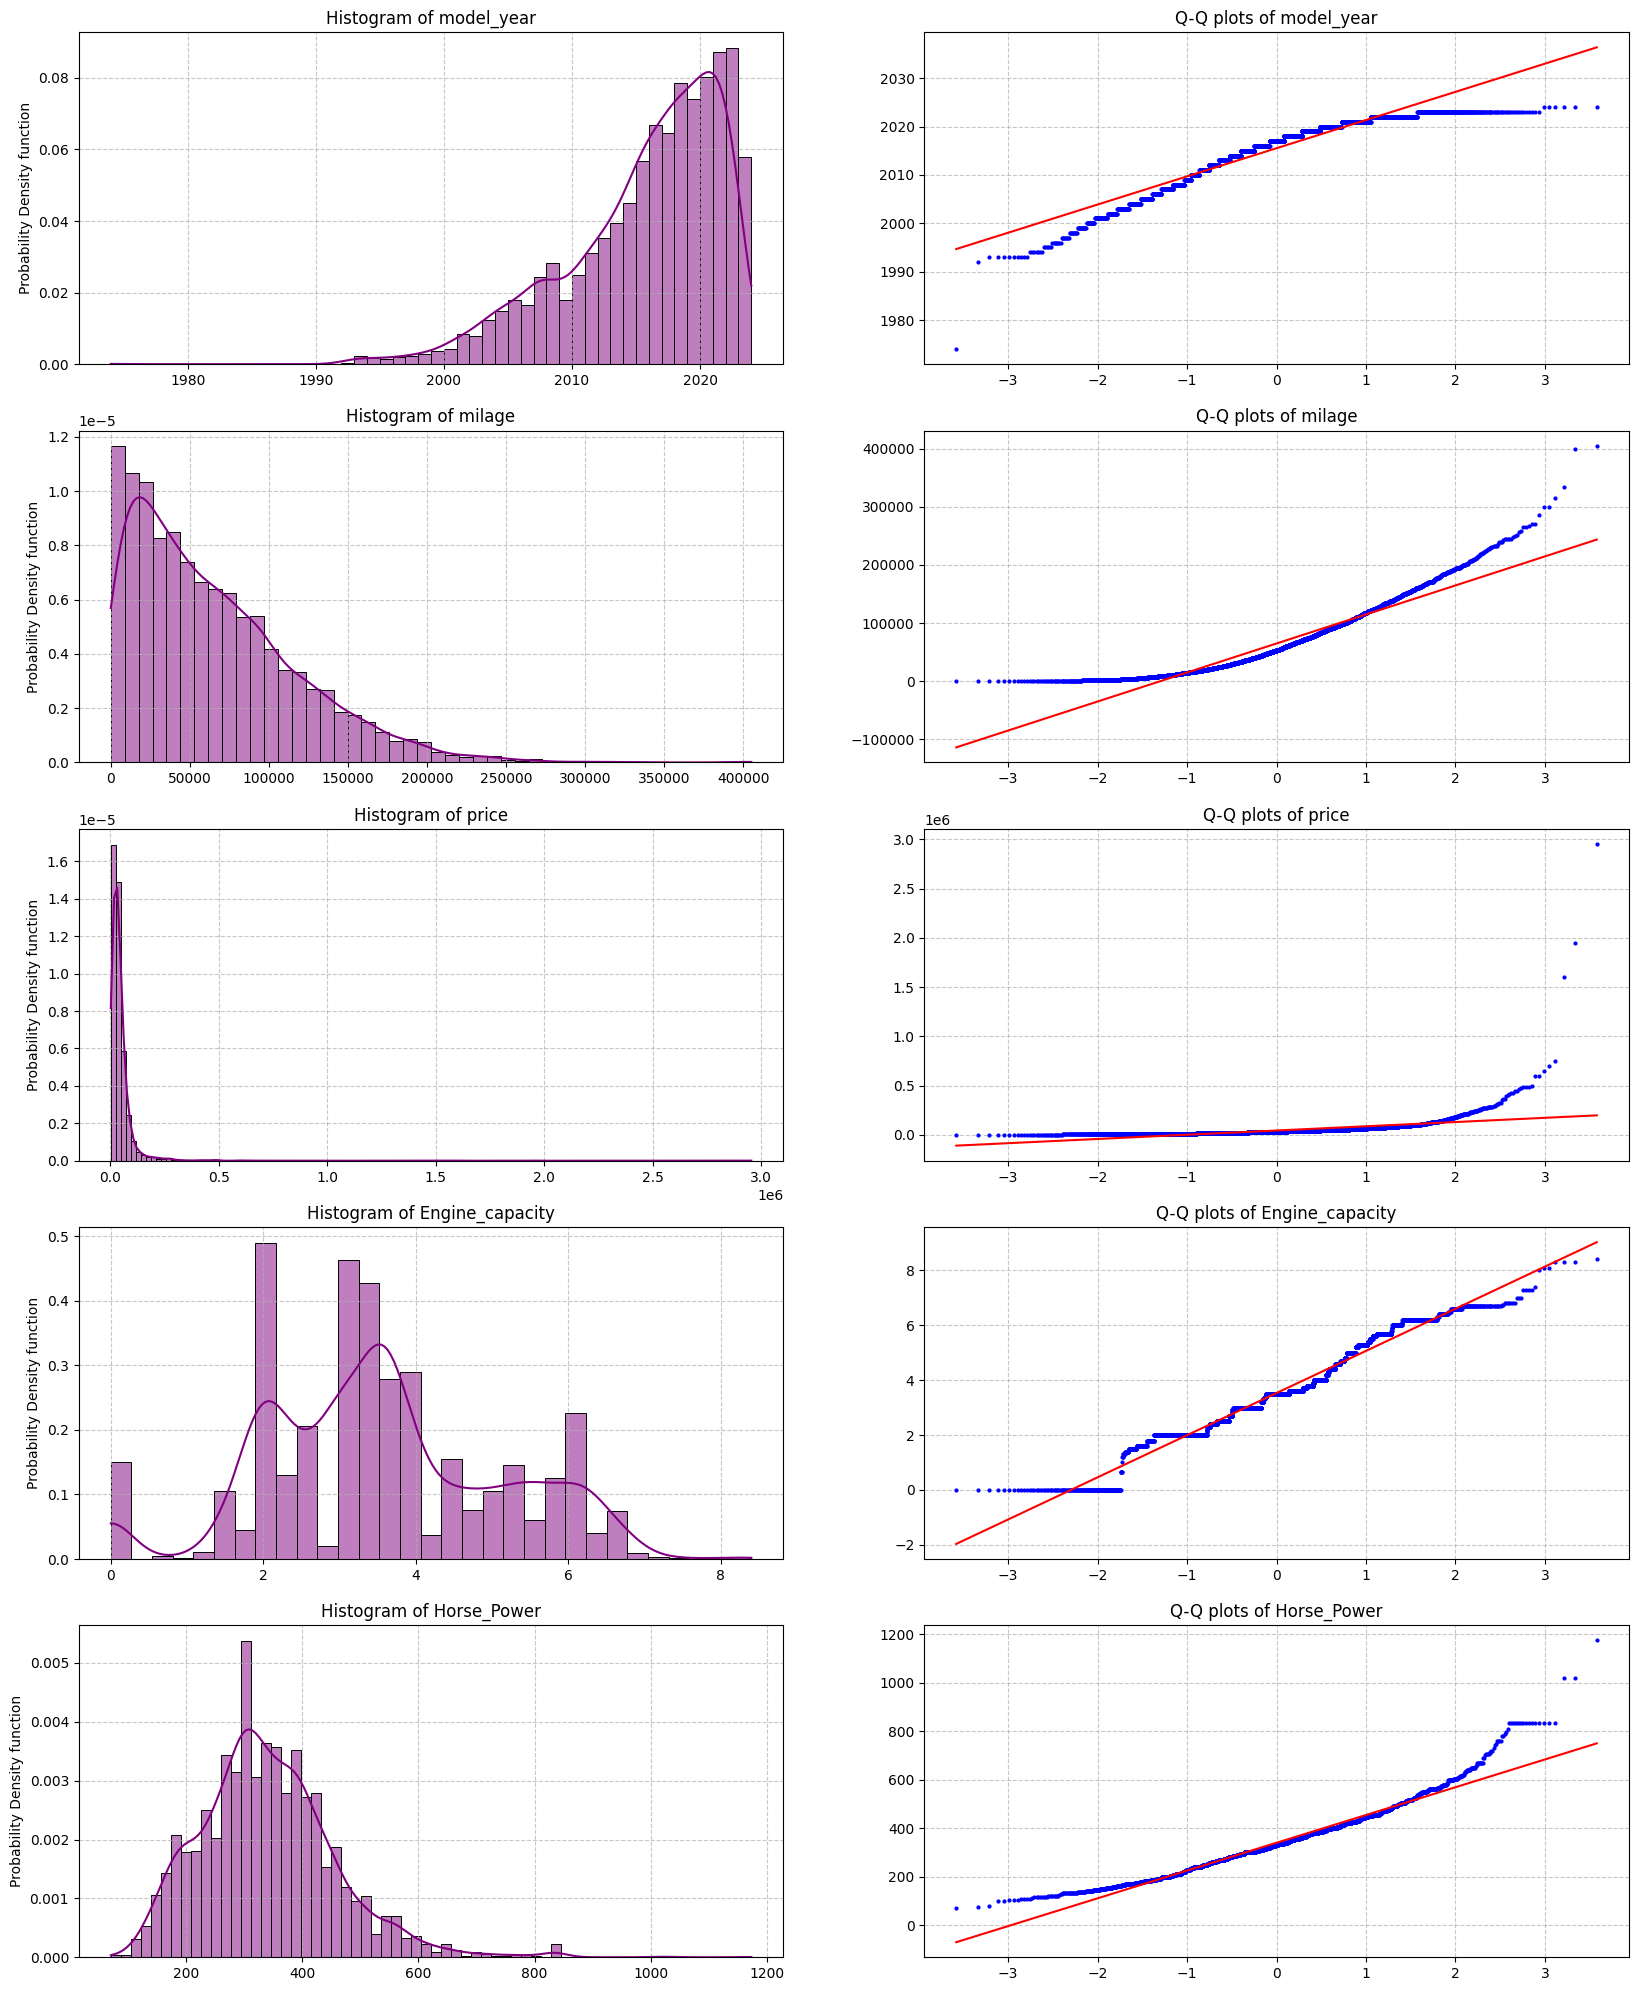

In [69]:
import scipy.stats as stats
num_cols=len(Numerical_Columns)
fig,axes=plt.subplots(num_cols,2,figsize=(20,num_cols*5))

for i,cols in enumerate(Numerical_Columns):
    sns.histplot(df[cols],kde=True,color='purple',ax=axes[i,0],stat='density',linewidth=0.7)
    axes[i,0].set_title(f"Histogram of {cols}")
    axes[i,0].set_xlabel("")
    axes[i,0].set_ylabel("Probability Density function")
    axes[i,0].grid(True,linestyle='--',alpha=0.7)

    stats.probplot(df[cols],plot=axes[i,1],dist='norm',fit=True)
    axes[i,1].set_title(f"Q-Q plots of {cols}")
    axes[i,1].set_ylabel(f"")
    axes[i,1].set_xlabel(f"")
    axes[i,1].grid(True,linestyle='--',alpha=0.7)
    axes[i,1].get_lines()[0].set_markersize(2)


LOGARITHMIC PLOT

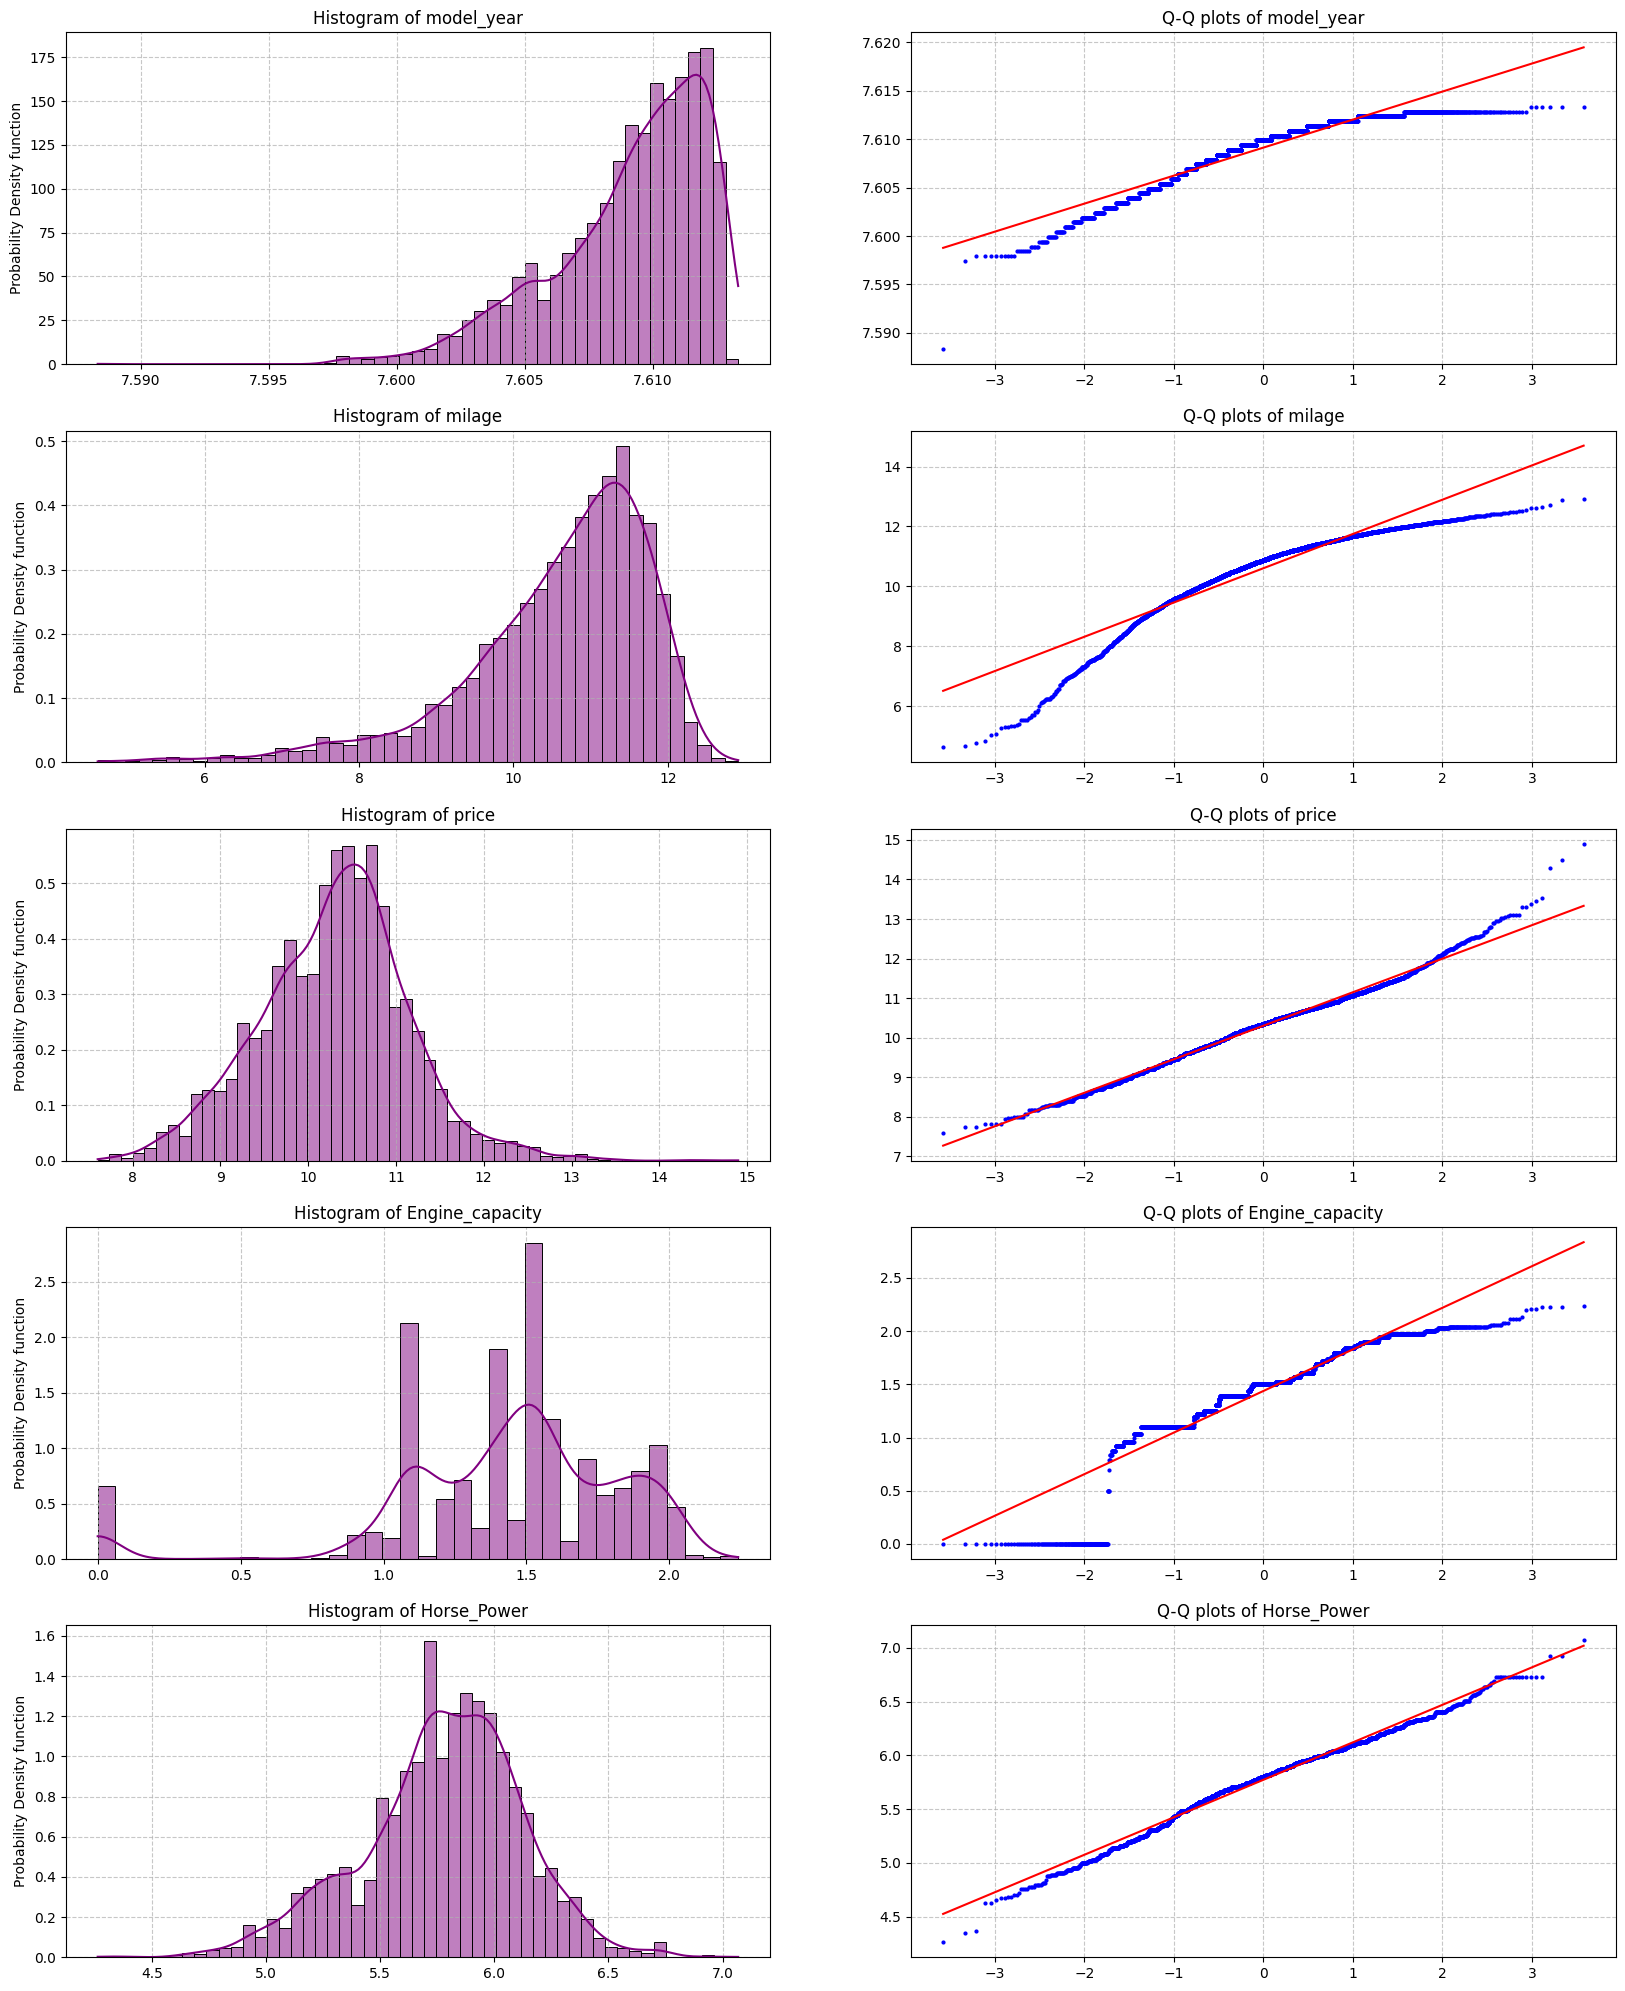

In [70]:
import scipy.stats as stats
num_cols=len(Numerical_Columns)
fig,axes=plt.subplots(num_cols,2,figsize=(20,num_cols*5))

for i,cols in enumerate(Numerical_Columns):
    sns.histplot(np.log1p(df[cols]),kde=True,color='purple',ax=axes[i,0],stat='density',linewidth=0.7)
    axes[i,0].set_title(f"Histogram of {cols}")
    axes[i,0].set_xlabel("")
    axes[i,0].set_ylabel("Probability Density function")
    axes[i,0].grid(True,linestyle='--',alpha=0.7)

    stats.probplot(np.log1p(df[cols]),plot=axes[i,1],dist='norm',fit=True)
    axes[i,1].set_title(f"Q-Q plots of {cols}")
    axes[i,1].set_ylabel(f"")
    axes[i,1].set_xlabel(f"")
    axes[i,1].grid(True,linestyle='--',alpha=0.7)
    axes[i,1].get_lines()[0].set_markersize(2)


EXPONENTIAL PLOT

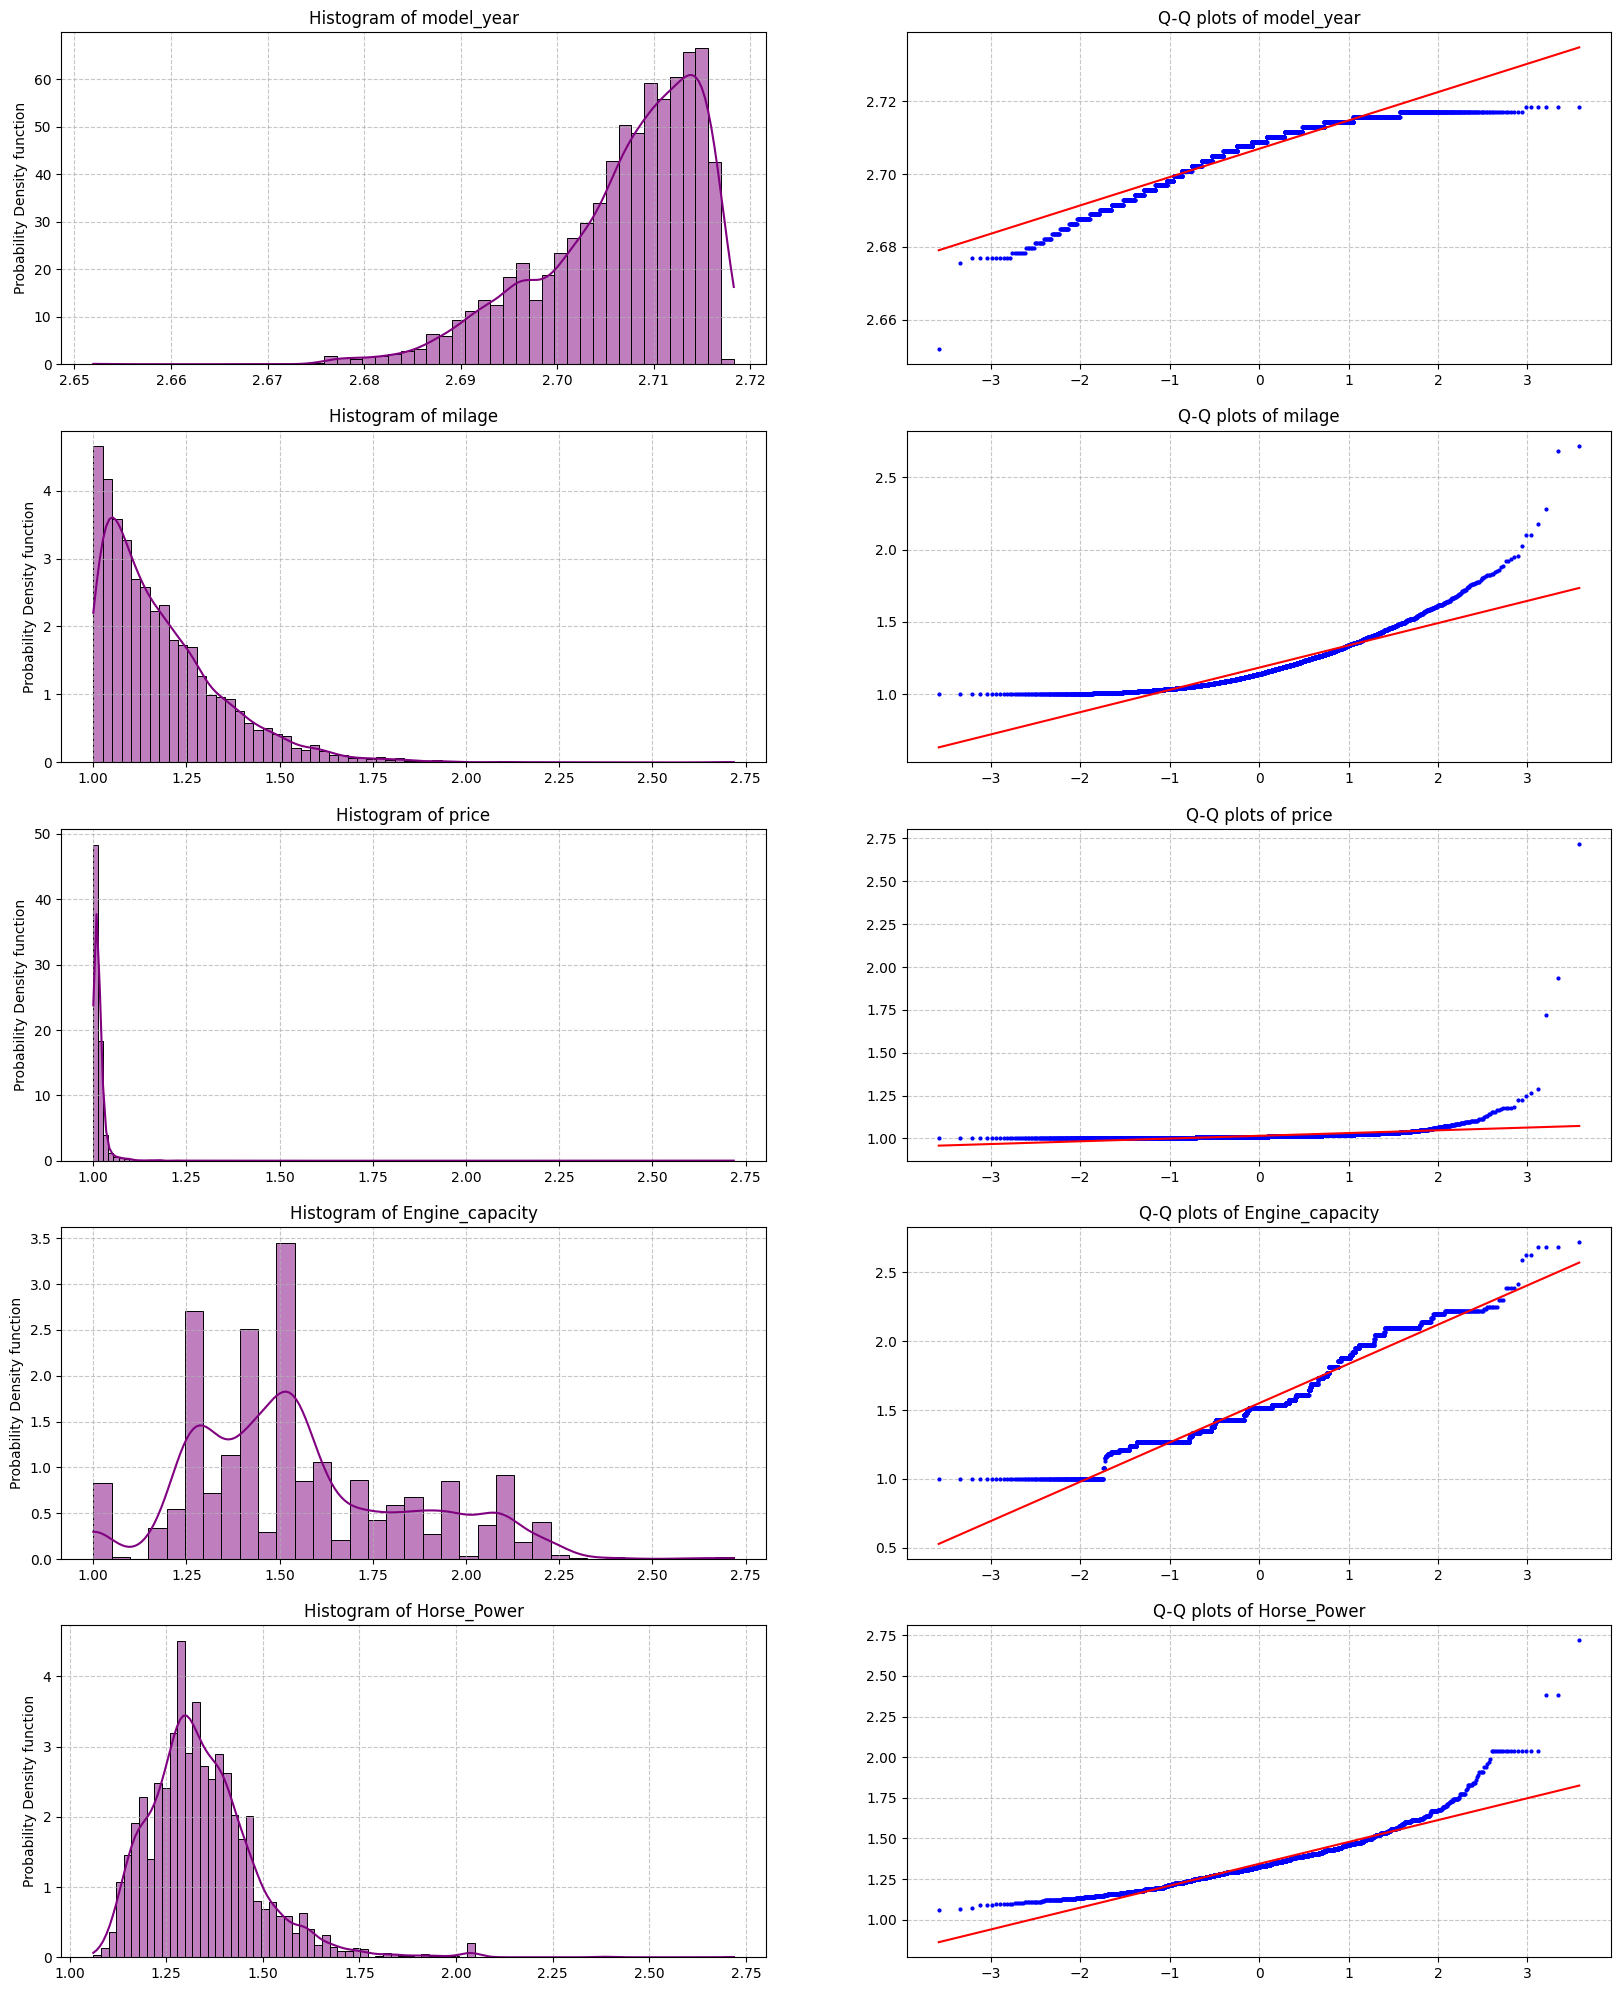

In [71]:
import scipy.stats as stats
num_cols=len(Numerical_Columns)
fig,axes=plt.subplots(num_cols,2,figsize=(20,num_cols*5))

for i,cols in enumerate(Numerical_Columns):
    scaled_data = df[cols] / df[cols].max()
    exp_data = np.exp(scaled_data)
    sns.histplot(exp_data,kde=True,color='purple',ax=axes[i,0],stat='density',linewidth=0.7)
    axes[i,0].set_title(f"Histogram of {cols}")
    axes[i,0].set_xlabel("")
    axes[i,0].set_ylabel("Probability Density function")
    axes[i,0].grid(True,linestyle='--',alpha=0.7)

    stats.probplot(exp_data,plot=axes[i,1],dist='norm',fit=True)
    axes[i,1].set_title(f"Q-Q plots of {cols}")
    axes[i,1].set_ylabel(f"")
    axes[i,1].set_xlabel(f"")
    axes[i,1].grid(True,linestyle='--',alpha=0.7)
    axes[i,1].get_lines()[0].set_markersize(2)


      price  Horse_Power  Engine_capacity    milage
0  0.002812     0.208470         0.440476  0.125710
1  0.012196     0.286579         0.452381  0.085557
2  0.017817     0.292197         0.416667  0.055006
3  0.004573     0.257415         0.416667  0.219313
4  0.011178     0.239517         0.238095  0.024043


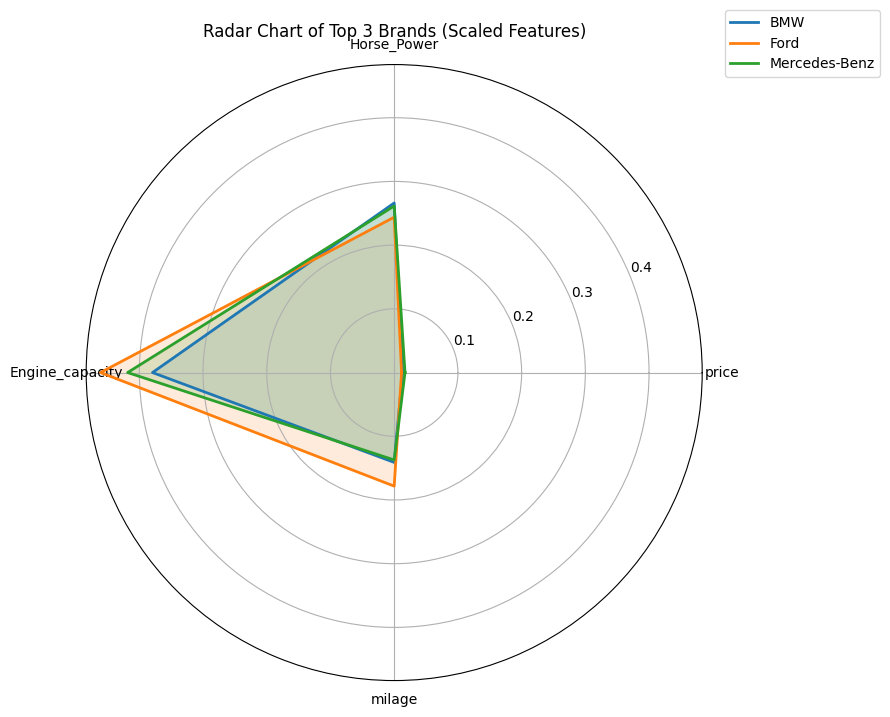

In [72]:
from sklearn.preprocessing import MinMaxScaler

features = ['price', 'Horse_Power', 'Engine_capacity', 'milage']

scaler = MinMaxScaler()
df_scaled = df.copy()

df_scaled[features] = scaler.fit_transform(df[features])

print(df_scaled[features].head())


# Select top 3 brands by count
top_brands = df_scaled['brand'].value_counts().head(3).index

# Compute mean of scaled features for those brands
brand_means = df_scaled[df_scaled['brand'].isin(top_brands)].groupby('brand')[features].mean()

# Number of variables
num_vars = len(features)

# Create angles for radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]   # close the loop

# Create plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each brand
for brand in brand_means.index:
    values = brand_means.loc[brand].tolist()
    values += values[:1]   # close the loop
    
    ax.plot(angles, values, linewidth=2, label=brand)
    ax.fill(angles, values, alpha=0.15)

# Set feature labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)

# Title and legend
ax.set_title("Radar Chart of Top 3 Brands (Scaled Features)", pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

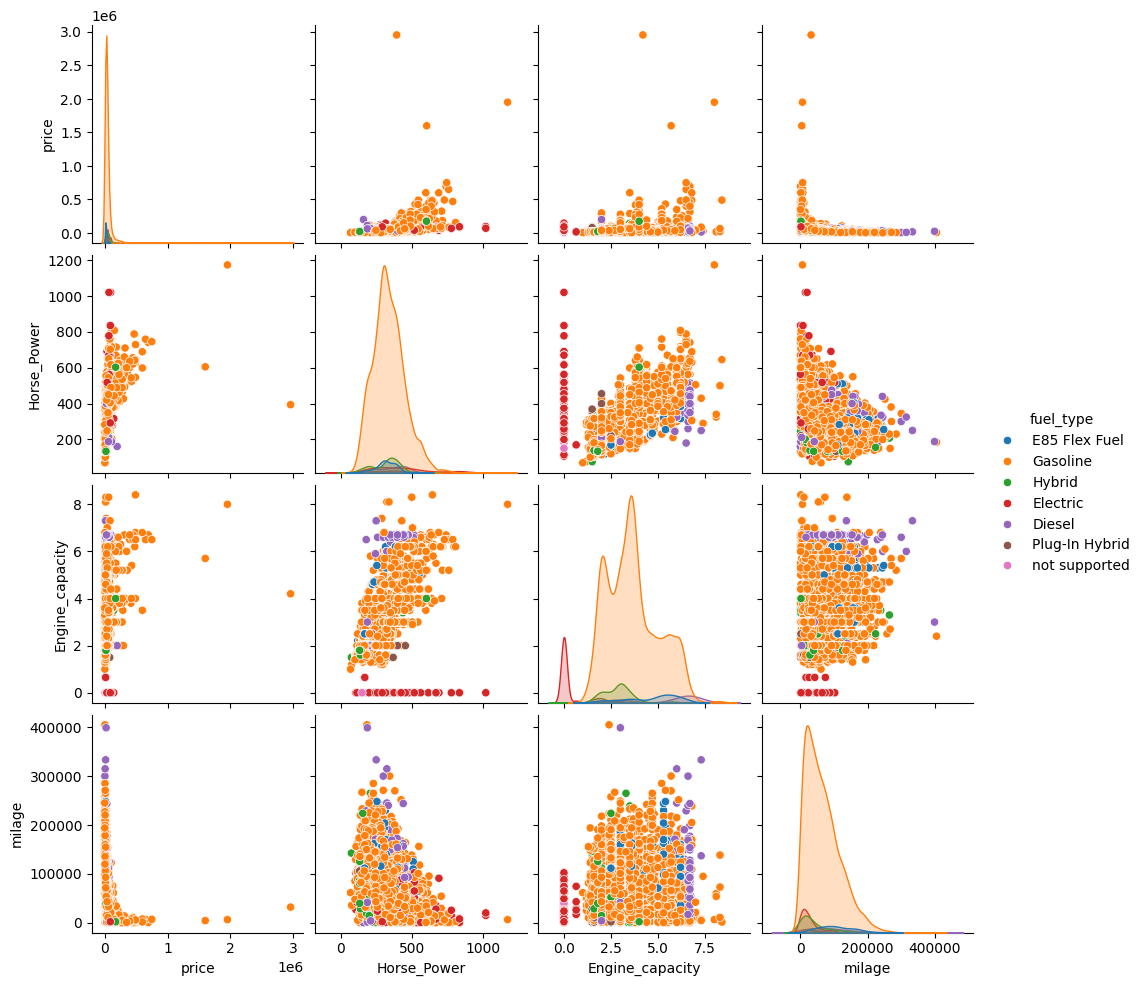

In [73]:
sns.pairplot(
    df,
    vars=['price', 'Horse_Power', 'Engine_capacity', 'milage'],
    hue='fuel_type'
)
plt.show()

<h2>2.Stastistical Inference Method

VARIOUS TESTS FOR NORMALITY


In [74]:
def testing_normality(df,col):
    print("-"*70)
    print(f"Normality test for *{col}*")
    print("-"*70)

    #Shapiro Test
    stat,p = shapiro(df[col])
    print(f"Shapiro-wilk test: stat={stat:.4f},p={p:.4f} -> {'Normal' if p>0.5 else 'Not Normal'}")

    #Jarque Bera Test
    jb_stats,jb_p=jarque_bera(df[col])
    print(f"Jarque Bera test: stat={jb_stats:.4f},p={jb_p:.4f} -> {'Normal' if jb_p>0.5 else 'Not Normal'}")
    
    #Anderson Darling Test
    value=anderson(df[col])
    critical_value=value.critical_values[2]
    print(f"Anderson Darlings test: stat={value.statistic:.4f},critical value={critical_value:.4f} -> {"Normal" if value.statistic<critical_value else "Not Normal"}")

    #Kolmogorov–Smirnov (KS) Test
    ks_stat, ks_p = kstest(df[col], 'norm')
    print(f"KS test: stat={ks_stat:.4f}, p={ks_p:.4f}  -> {'Normal' if ks_p>0.5 else 'Not Normal'} ")

    #Lilliefors Test
    lf_stat,lf_p = lilliefors(df[col])
    print(f"Lilliefors test: stat={lf_stat:.4f}, p={lf_p:.4f}  -> {'Normal' if lf_p>0.5 else 'Not Normal'} ")

    #D’Agostino and Pearson’s Test
    dp_stat, dp_p = normaltest(df[col])
    print(f"D'Agostino-Pearson test: stat={dp_stat:.4f}, p={dp_p:.4f} -> {'Normal' if dp_p>0.5 else 'Not Normal'}")

for col in Numerical_Columns:
    testing_normality(df,col)


----------------------------------------------------------------------
Normality test for *model_year*
----------------------------------------------------------------------
Shapiro-wilk test: stat=0.9090,p=0.0000 -> Not Normal
Jarque Bera test: stat=993.7930,p=0.0000 -> Not Normal
Anderson Darlings test: stat=102.2070,critical value=0.7860 -> Not Normal
KS test: stat=1.0000, p=0.0000  -> Not Normal 
Lilliefors test: stat=0.1295, p=0.0010  -> Not Normal 
D'Agostino-Pearson test: stat=630.5740, p=0.0000 -> Not Normal
----------------------------------------------------------------------
Normality test for *milage*
----------------------------------------------------------------------
Shapiro-wilk test: stat=0.9105,p=0.0000 -> Not Normal
Jarque Bera test: stat=1407.6247,p=0.0000 -> Not Normal
Anderson Darlings test: stat=85.9013,critical value=0.7860 -> Not Normal
KS test: stat=1.0000, p=0.0000  -> Not Normal 
Lilliefors test: stat=0.1083, p=0.0010  -> Not Normal 
D'Agostino-Pearson test

<h2>Removing Outliers (if necessary)

<h3>OUTLIER DETECTION USING IQR METHOD 

In [75]:
def detect_outliers_using_iqr(data):
    outlier_mask=pd.Series(index=data.columns,dtype=bool)

    for col in data.columns:
        if col in Numerical_Columns:
            Q1=data[col].quantile(0.25)
            Q3=data[col].quantile(0.75)
            IQR=Q3-Q1
            lower_bound=Q1-1.5*IQR
            upper_bound=Q3+1.5*IQR
            col_outliers_mask=(
                (data[col]<lower_bound)|(data[col]>upper_bound)
            )
            outlier_mask[col]=col_outliers_mask.any()

    return outlier_mask

outliers_iqr_mask=detect_outliers_using_iqr(df)
print("\nOutliers detected using IQR is: ")
for col,is_outlier in outliers_iqr_mask.items():
    print(f"{col} : {is_outlier}")


Outliers detected using IQR is: 
brand : True
model : True
model_year : True
milage : True
fuel_type : True
engine : True
transmission : True
ext_col : True
int_col : True
clean_title : True
price : True
Accident_occured : True
Engine_capacity : True
Horse_Power : True
Cylinders : True


In [76]:
def detect_outliers_using_zscore(data,threshold=3):
    outlier_mask=pd.Series(index=data.columns,dtype=bool)

    for col in data.columns:
        if col in Numerical_Columns:
            mean=np.mean(data[col])
            std_deviation=np.std(data[col])
            z_scores=np.abs((data[col]-mean)/std_deviation)
            col_outliers_mask=z_scores>threshold
            outlier_mask[col]=col_outliers_mask.any()

    return outlier_mask

outliers_iqr_mask=detect_outliers_using_zscore(df)
print("\nOutliers detected using Z-Score is: ")
for col,is_outlier in outliers_iqr_mask.items():
    print(f"{col} : {is_outlier}")


Outliers detected using Z-Score is: 
brand : True
model : True
model_year : True
milage : True
fuel_type : True
engine : True
transmission : True
ext_col : True
int_col : True
clean_title : True
price : True
Accident_occured : True
Engine_capacity : True
Horse_Power : True
Cylinders : True


<h2>REMOVAL OF OUTLIERS USING IQR

In [77]:
"""
def remove_outliers_iqr(data,Numerical_Columns):
    cleaned_data=data.copy()

    for col in Numerical_Columns:
        Q1=cleaned_data[col].quantile(0.25)
        Q3=cleaned_data[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        cleaned_data=cleaned_data[
            (cleaned_data[col]>=lower_bound)&
            (cleaned_data[col]<=upper_bound)
        ]

    return cleaned_data
cleaned_data_iqr=remove_outliers_iqr(df,Numerical_Columns)
print("Dataframe after removing Outliers using IQR Method: ")
print(cleaned_data_iqr)
"""

'\ndef remove_outliers_iqr(data,Numerical_Columns):\n    cleaned_data=data.copy()\n\n    for col in Numerical_Columns:\n        Q1=cleaned_data[col].quantile(0.25)\n        Q3=cleaned_data[col].quantile(0.75)\n        IQR=Q3-Q1\n        lower_bound=Q1-1.5*IQR\n        upper_bound=Q3+1.5*IQR\n        cleaned_data=cleaned_data[\n            (cleaned_data[col]>=lower_bound)&\n            (cleaned_data[col]<=upper_bound)\n        ]\n\n    return cleaned_data\ncleaned_data_iqr=remove_outliers_iqr(df,Numerical_Columns)\nprint("Dataframe after removing Outliers using IQR Method: ")\nprint(cleaned_data_iqr)\n'

In [78]:
"""
# Create individual box plots for each numerical column
fig, axes = plt.subplots(1, len(Numerical_Columns), figsize=(10*len(Numerical_Columns), 10))


for idx, col in enumerate(Numerical_Columns):
    axes[idx].boxplot(cleaned_data_iqr[col], 
                      patch_artist=True,
                      showmeans=True,
                      meanprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8})
    axes[idx].set_title(f'{col} - After Outlier Removal', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)
    
   

plt.suptitle('Box Plots After IQR Outlier Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
"""

"\n# Create individual box plots for each numerical column\nfig, axes = plt.subplots(1, len(Numerical_Columns), figsize=(10*len(Numerical_Columns), 10))\n\n\nfor idx, col in enumerate(Numerical_Columns):\n    axes[idx].boxplot(cleaned_data_iqr[col], \n                      patch_artist=True,\n                      showmeans=True,\n                      meanprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8})\n    axes[idx].set_title(f'{col} - After Outlier Removal', fontsize=12, fontweight='bold')\n    axes[idx].set_ylabel('Value')\n    axes[idx].grid(True, alpha=0.3)\n\n\n\nplt.suptitle('Box Plots After IQR Outlier Removal', fontsize=14, fontweight='bold')\nplt.tight_layout()\nplt.show()\n"

In [79]:
df.drop('engine',axis=1,inplace=True)

In [80]:
df.drop('Cylinders',axis=1,inplace=True)

In [81]:
df.to_csv('../data/processed_data.csv',index=False)

<h3>Machine Learning Implementation

In [82]:
data=pd.read_csv('../data/processed_data.csv')

In [83]:
Target_cols='price'
X=data.drop(columns=[Target_cols])
y=data[Target_cols]

low=y.quantile(0.01)
high=y.quantile(0.99)

mask=(y>=low)&(y<=high)
X=X[mask]
Y=y[mask]

X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)


In [84]:
num_cols=X_train.select_dtypes(include=np.number).columns.to_list()
cat_cols=X_train.select_dtypes(exclude=np.number).columns.to_list()

low_card_cols=[c for c in cat_cols if X_train[c].nunique()<=10]
mid_card_cols=[c for c in cat_cols if 10<X_train[c].nunique()<=50]
high_card_cols=[c for c in cat_cols if X_train[c].nunique()>50]

print('Low:',low_card_cols)
print('Mid:',mid_card_cols)
print('High:',high_card_cols)

Low: ['fuel_type', 'clean_title', 'Accident_occured']
Mid: []
High: ['brand', 'model', 'transmission', 'ext_col', 'int_col']


Custom sklearn transformer for Frequency Encoding

In [85]:
class FrequencyEncoder(BaseEstimator,TransformerMixin):
    def __init__(self,cols):
        self.cols=cols
        self.maps={}

    def fit(self,X,y=None):
        for col in self.cols:
            self.maps[col]= X[col].value_counts(normalize=True)
        return self
    
    def transform(self,X):
        X=X.copy()
        for col in self.cols:
            X[col]=X[col].map(self.maps[col]).fillna(0)
        return X

In [86]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols+high_card_cols),
        ('low_card',OneHotEncoder(handle_unknown='ignore'),low_card_cols),
        ('mid_card',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1),mid_card_cols),
        
        
    ]
)

In [87]:
numerical_columns=df.select_dtypes(include=np.number).columns.to_list()

In [88]:
df[numerical_columns].head()

,model_year,milage,price,Engine_capacity,Horse_Power
0,2013,51000.0,10300.0,3.7,300.000000
1,2021,34742.0,38005.0,3.8,386.175639
2,2022,22372.0,54598.0,3.5,392.374551
3,2015,88900.0,15500.0,3.5,354.000000
4,2021,9835.0,34999.0,2.0,334.254113


In [89]:
feature_selector=SelectFromModel(Lasso(alpha=0.001))

In [90]:
model=Pipeline(steps=[
    ('freq',FrequencyEncoder(high_card_cols)),
    ('preprocessor',preprocessor),
    ('Feature_selector',feature_selector),
    ('regressor',TransformedTargetRegressor(
        regressor=Ridge(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

In [91]:
model.fit(X_train,y_train)

c:\AI_Project\MACHINE_LEARNING\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.057e+11, tolerance: 3.249e+08
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('freq', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['brand', 'model', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_card', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

In [92]:
def evaluate(model,X_tr,y_tr,X_te,y_te):
    train_pred=model.predict(X_tr)
    test_pred=model.predict(X_te)

    print("\n Train Results \n")
    print("MAE: ",mean_absolute_error(y_tr,train_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_tr,train_pred)))
    print("R2: ",r2_score(y_tr,train_pred))


    print("\n Test Results \n")
    print("MAE: ",mean_absolute_error(y_te,test_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_te,test_pred)))
    print("R2: ",r2_score(y_te,test_pred))



In [93]:
evaluate(model,X_train,y_train,X_test,y_test)


 Train Results 

MAE:  11957.909051565524
RMSE:  24597.07954035308
R2:  0.48746645010543077

 Test Results 

MAE:  12500.654211431502
RMSE:  25489.79260457383
R2:  0.4943690489622824


Hyper Parameter Tuning

In [94]:
param_grid={
    'regressor__regressor__alpha':[0.1,1,5,10,20,50]
}

grid=GridSearchCV(model,param_grid,cv=5,scoring='r2',n_jobs=-1)
grid.fit(X_train,y_train)

print("Beat_Model: ",grid.best_estimator_)
print("Best_Alpha: ",grid.best_params_)

c:\AI_Project\MACHINE_LEARNING\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.057e+11, tolerance: 3.249e+08
  model = cd_fast.enet_coordinate_descent(


Beat_Model:  Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('low_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clean_title',
                                                   'Accident_occured']),
                                        

In [95]:
evaluate(grid.best_estimator_,X_train,y_train,X_test,y_test)


 Train Results 

MAE:  11882.127343826756
RMSE:  24520.486468598847
R2:  0.4906534462105462

 Test Results 

MAE:  12406.544242197095
RMSE:  25419.221258739646
R2:  0.49716496503687213


#Decision Tree Algorithm

In [96]:
dt_model=Pipeline(steps=[
    ('freq',FrequencyEncoder(high_card_cols)),
    ('preprocessor',preprocessor),
    ('Feature_selector',feature_selector),
    ('regressor',TransformedTargetRegressor(
        regressor=DecisionTreeRegressor(max_depth=10,random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])
dt_model.fit(X_train,y_train)

c:\AI_Project\MACHINE_LEARNING\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.057e+11, tolerance: 3.249e+08
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('freq', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['brand', 'model', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_card', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

In [97]:
evaluate(dt_model,X_train,y_train,X_test,y_test)


 Train Results 

MAE:  4526.4580235410895
RMSE:  9200.62422710958
R2:  0.9282883367964503

 Test Results 

MAE:  11657.876936449626
RMSE:  21012.936609642245
R2:  0.6563830747227726


In [98]:
param_grid_dt={
    'regressor__regressor__max_depth':[5,10,20,25,None],
    'regressor__regressor__min_samples_split':[2,5,10],
    'regressor__regressor__min_samples_leaf':[1,2,4],
    'regressor__regressor__max_features':['sqrt','log2',None],
    'regressor__regressor__max_leaf_nodes':[None,10,50,100]

}

grid=GridSearchCV(dt_model,param_grid_dt,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1,verbose=2)
grid.fit(X_train,y_train)

best_dt=grid.best_estimator_
print("Beat_Model: ",best_dt)
print("Best_Alpha: ",grid.best_params_)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


c:\AI_Project\MACHINE_LEARNING\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.057e+11, tolerance: 3.249e+08
  model = cd_fast.enet_coordinate_descent(


Beat_Model:  Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('low_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clea...
                                                   'Accident_occured']),
                                              

In [99]:
evaluate(best_dt,X_train,y_train,X_test,y_test)


 Train Results 

MAE:  6140.418157458733
RMSE:  12469.502825530471
R2:  0.8682794656059233

 Test Results 

MAE:  10997.722946091508
RMSE:  19062.011864934226
R2:  0.7172266234402765


In [100]:
rf_model=Pipeline(steps=[
    ('freq',FrequencyEncoder(high_card_cols)),
    ('preprocessor',preprocessor),
    ('Feature_selector',feature_selector),
    ('regressor',TransformedTargetRegressor(
        regressor=RandomForestRegressor(n_estimators=400,max_depth=None,random_state=42,n_jobs=-1),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])
rf_model.fit(X_train,y_train)

c:\AI_Project\MACHINE_LEARNING\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.057e+11, tolerance: 3.249e+08
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('freq', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['brand', 'model', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_card', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

In [101]:
evaluate(rf_model,X_train,y_train,X_test,y_test)


 Train Results 

MAE:  3109.668102680538
RMSE:  6898.263057462422
R2:  0.9596879660216086

 Test Results 

MAE:  8442.610024798721
RMSE:  15017.466508563439
R2:  0.8244930209910656


In [102]:
"""
param_grid_rf={
    'regressor__regressor__max_depth':[5,10,20,25,None],
    'regressor__regressor__n_estimators':[100,200,400,500,None],
    'regressor__regressor__min_samples_split':[2,5,10],
    'regressor__regressor__min_samples_leaf':[1,2,4],
    'regressor__regressor__max_features':['sqrt','log2',None],
    

}

grid=GridSearchCV(rf_model,param_grid_rf,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1,verbose=2)
grid.fit(X_train,y_train)

print("Beat_Model: ",grid.best_estimator_)
print("Best_Alpha: ",grid.best_params_)
"""

'\nparam_grid_rf={\n    \'regressor__regressor__max_depth\':[5,10,20,25,None],\n    \'regressor__regressor__n_estimators\':[100,200,400,500,None],\n    \'regressor__regressor__min_samples_split\':[2,5,10],\n    \'regressor__regressor__min_samples_leaf\':[1,2,4],\n    \'regressor__regressor__max_features\':[\'sqrt\',\'log2\',None],\n\n\n}\n\ngrid=GridSearchCV(rf_model,param_grid_rf,cv=5,scoring=\'neg_root_mean_squared_error\',n_jobs=-1,verbose=2)\ngrid.fit(X_train,y_train)\n\nprint("Beat_Model: ",grid.best_estimator_)\nprint("Best_Alpha: ",grid.best_params_)\n'

In [103]:
#evaluate(grid.best_estimator_,X_train,y_train,X_test,y_test)

In [104]:
from xgboost import XGBRegressor
xg_model=Pipeline(steps=[
    ('freq',FrequencyEncoder(high_card_cols)),
    ('preprocessor',preprocessor),
    ('regressor',TransformedTargetRegressor(
        regressor=XGBRegressor(
            obejective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

xg_model.fit(X_train,y_train)

c:\AI_Project\MACHINE_LEARNING\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:45:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "obejective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('freq', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cols,"['brand', 'model', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_card', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3

In [105]:
evaluate(xg_model,X_train,y_train,X_test,y_test)


 Train Results 

MAE:  1903.1701340786246
RMSE:  3327.182412624345
R2:  0.9906220388026976

 Test Results 

MAE:  7813.968515790519
RMSE:  14257.255711186403
R2:  0.8418122224163689


In [106]:
param_grid={
    'regressor__regressor__n_estimators':[100,300,500],
    'regressor__regressor__max_depth':[3,5,7],
    'regressor__regressor__learning_rate':[0.01,0.05,0.1],
    'regressor__regressor__subsample':[0.7,0.9,1.0]
}

grid=GridSearchCV(xg_model,param_grid,cv=5,scoring='r2',n_jobs=-1,verbose=2)
grid.fit(X_train,y_train)

best_xg=grid.best_estimator_
print("Best_Model",best_xg)
print("Best_Alpha",grid.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


c:\AI_Project\MACHINE_LEARNING\env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:48:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "obejective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best_Model Pipeline(steps=[('freq',
                 FrequencyEncoder(cols=['brand', 'model', 'transmission',
                                        'ext_col', 'int_col'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['model_year', 'milage',
                                                   'Engine_capacity',
                                                   'Horse_Power', 'brand',
                                                   'model', 'transmission',
                                                   'ext_col', 'int_col']),
                                                 ('low_card',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel_type', 'clea...
                                                                   feature_weights=None,
                                

In [107]:
evaluate(best_xg,X_train,y_train,X_test,y_test)


 Train Results 

MAE:  3312.093297381734
RMSE:  5875.412981821749
R2:  0.9707563212059824

 Test Results 

MAE:  7324.537658484507
RMSE:  12997.53527180473
R2:  0.868531091893185


In [108]:
os.makedirs('../ML_Models',exist_ok=True)

In [109]:
import joblib
joblib.dump(best_xg,'../ML_Models/best_xgboostregressor.pk1')

['../ML_Models/best_xgboostregressor.pk1']

In [110]:
joblib.dump(preprocessor, "../ML_Models/preprocessor.pkl")

['../ML_Models/preprocessor.pkl']